<a href="https://colab.research.google.com/github/RoyalMaddy08/BEAD/blob/main/revision_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# BLOCK 1 : IMPORT LIBRARIES
# ============================================================

import os
import glob
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Enhanced RSNN Battery Digital Twin")
print("="*60)
print(f"PyTorch Version : {torch.__version__}")
print(f"Device          : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

print("="*60)

Enhanced RSNN Battery Digital Twin
PyTorch Version : 2.11.0+cu128
Device          : cuda
GPU             : Tesla T4


In [7]:
# ============================================================
# BLOCK 2 : CONFIGURATION
# ============================================================

# -----------------------------
# Dataset
# -----------------------------
DATASET_NAME = "Panasonic"

# Folder containing the 10 CSV files
DATASET_PATH = "/content/01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv"

# -----------------------------
# Features
# -----------------------------
FEATURE_COLUMNS = [
    "Voltage_V",
    "Current_A",
    "Temperature_C",
    "Capacity_Ah",
    "Power_W",
    "Energy_Wh"
]

TARGET_COLUMN = "SOC"

# -----------------------------
# Sequence parameters
# -----------------------------
SEQUENCE_LENGTH = 100

# Use overlapping windows.
# We can later compare stride=1, 2, 5, 10.
STRIDE = 5

# -----------------------------
# Train / Validation / Test
# -----------------------------
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# -----------------------------
# Training
# -----------------------------
BATCH_SIZE = 64

EPOCHS = 50

LEARNING_RATE = 1e-3

# -----------------------------
# RSNN
# -----------------------------
TIME_STEPS = 50

RESERVOIR_SIZE = 100

RESERVOIR_DENSITY = 0.10

LEAK_BETA = 0.95

THRESHOLD = 1.0

# -----------------------------
# Population Encoding
# -----------------------------
NEURONS_PER_FEATURE = 10

# -----------------------------
# Print Configuration
# -----------------------------
print("="*60)
print("CONFIGURATION")
print("="*60)

print(f"Dataset           : {DATASET_NAME}")
print(f"Features          : {len(FEATURE_COLUMNS)}")
print(f"Sequence Length   : {SEQUENCE_LENGTH}")
print(f"Stride            : {STRIDE}")
print(f"Reservoir Size    : {RESERVOIR_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Epochs            : {EPOCHS}")

print("="*60)

CONFIGURATION
Dataset           : Panasonic
Features          : 6
Sequence Length   : 100
Stride            : 5
Reservoir Size    : 100
Batch Size        : 64
Epochs            : 50


In [10]:
import os

print("Current Working Directory:")
print(os.getcwd())

print("\nFiles in /content:")
print(os.listdir("/content"))

Current Working Directory:
/content

Files in /content:
['.config', '04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '10.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '09.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', '02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', 'sample_data']


In [11]:
# ============================================================
# BLOCK 3 : LOAD PANASONIC DATASET
# ============================================================

import glob
import os
import pandas as pd

print("="*70)
print("LOADING PANASONIC DATASET")
print("="*70)

# Search directly in /content
csv_files = sorted(glob.glob("/content/*.csv"))

print(f"Found {len(csv_files)} CSV files\n")

assert len(csv_files) > 0, "❌ No CSV files found!"

all_data = []

for i, file in enumerate(csv_files):

    df = pd.read_csv(file)

    print(f"{i+1:02d}. {os.path.basename(file)}")
    print(f"   Shape      : {df.shape}")

    print(f"   SoC Range  : {df[TARGET_COLUMN].min():.4f} → {df[TARGET_COLUMN].max():.4f}")

    all_data.append(df)

battery_df = pd.concat(all_data, ignore_index=True)

print("\n" + "="*70)
print("MERGED DATASET")
print("="*70)

print(f"Total Samples : {len(battery_df):,}")
print(f"Columns       : {battery_df.columns.tolist()}")

display(battery_df.head())

LOADING PANASONIC DATASET
Found 10 CSV files

01. 01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3876 → 0.9257
02. 02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3136 → 0.9302
03. 03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3401 → 0.9296
04. 04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3012 → 0.9302
05. 05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3370 → 0.9197
06. 06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.0699 → 0.9064
07. 07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
   Shape      : (19428, 7)
   SoC Range  : 0.3187 → 0.9264
08. 08.0__Chopped_(Panasonic_7Feature

,Voltage_V,Current_A,Temperature_C,SOC,Capacity_Ah,Power_W,Energy_Wh
0,0.923911,0.579676,0.865355,0.923911,0.579676,0.923911,0.579676
1,0.868575,0.575080,0.865355,0.923824,0.579669,0.923055,0.579605
2,0.865724,0.574804,0.865546,0.923646,0.579654,0.921326,0.579461
3,0.869519,0.606585,0.865355,0.923470,0.579689,0.919664,0.579808
4,0.884662,0.606997,0.865355,0.923325,0.579774,0.918347,0.580643


DATA QUALITY ANALYSIS

Missing Values
----------------------------------------
Voltage_V        0
Current_A        0
Temperature_C    0
SOC              0
Capacity_Ah      0
Power_W          0
Energy_Wh        0
dtype: int64

Duplicate Rows
----------------------------------------
328

Feature Statistics
----------------------------------------


,mean,std,min,max
Voltage_V,0.602224,0.163971,-7.058909e-06,0.948995
Current_A,0.623636,0.060325,-1.577408e-06,0.964665
Temperature_C,0.540712,0.265531,5.947989e-07,0.999743
SOC,0.629923,0.143960,6.993518e-02,0.930218
Capacity_Ah,0.624552,0.017491,5.652998e-01,0.662927
Power_W,0.605362,0.151784,1.583803e-02,0.930218
Energy_Wh,0.623794,0.028318,5.026379e-01,0.671335


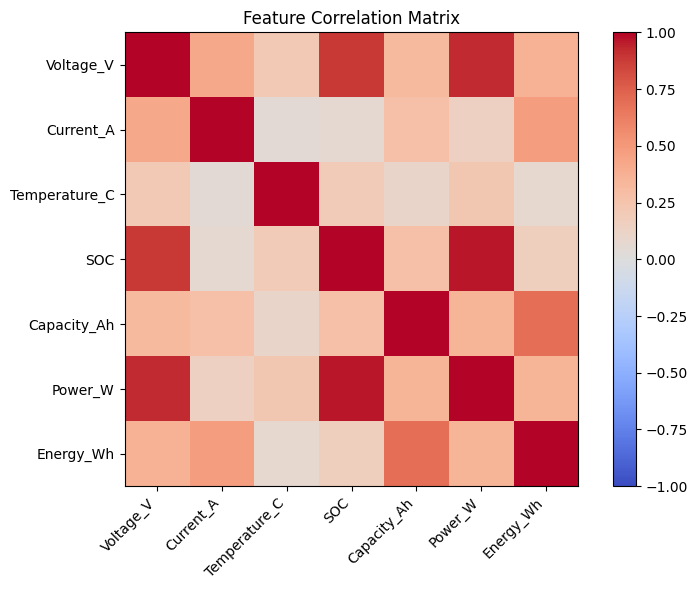

In [12]:
# ============================================================
# BLOCK 4 : DATA QUALITY & FEATURE ANALYSIS
# ============================================================

print("="*70)
print("DATA QUALITY ANALYSIS")
print("="*70)

# -----------------------------
# Missing values
# -----------------------------
print("\nMissing Values")
print("-"*40)
print(battery_df.isnull().sum())

# -----------------------------
# Duplicate rows
# -----------------------------
duplicates = battery_df.duplicated().sum()

print("\nDuplicate Rows")
print("-"*40)
print(duplicates)

# -----------------------------
# Basic statistics
# -----------------------------
print("\nFeature Statistics")
print("-"*40)

display(
    battery_df.describe().T[
        ["mean","std","min","max"]
    ]
)

# -----------------------------
# Correlation Matrix
# -----------------------------
plt.figure(figsize=(8,6))

corr = battery_df.corr()

im = plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

plt.colorbar(im)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

FEATURE CORRELATION ANALYSIS


,Voltage_V,Current_A,Temperature_C,SOC,Capacity_Ah,Power_W,Energy_Wh
Voltage_V,1.0000,0.4209,0.2107,0.8839,0.3141,0.9282,0.3678
Current_A,0.4209,1.0000,0.0407,0.0655,0.2790,0.1455,0.4707
Temperature_C,0.2107,0.0407,1.0000,0.1909,0.1081,0.2192,0.0748
SOC,0.8839,0.0655,0.1909,1.0000,0.2783,0.9618,0.1609
Capacity_Ah,0.3141,0.2790,0.1081,0.2783,1.0000,0.3499,0.6898
Power_W,0.9282,0.1455,0.2192,0.9618,0.3499,1.0000,0.3497
Energy_Wh,0.3678,0.4707,0.0748,0.1609,0.6898,0.3497,1.0000



Correlation with SOC
----------------------------------------
Power_W          0.961805
Voltage_V        0.883878
Capacity_Ah      0.278286
Temperature_C    0.190892
Energy_Wh        0.160876
Current_A        0.065524
Name: SOC, dtype: float64


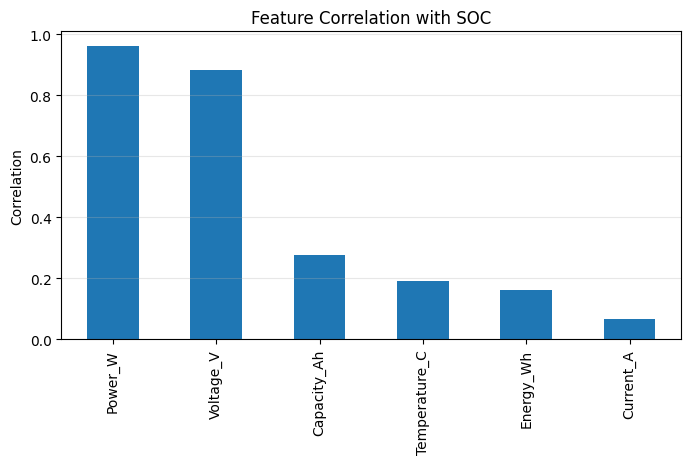

In [13]:
# ============================================================
# BLOCK 5 : FEATURE CORRELATION ANALYSIS
# ============================================================

print("="*70)
print("FEATURE CORRELATION ANALYSIS")
print("="*70)

corr = battery_df.corr()

# Display correlation values
display(corr.round(4))

# Correlation with SOC
print("\nCorrelation with SOC")
print("-"*40)

soc_corr = corr["SOC"].drop("SOC").sort_values(key=lambda x: abs(x), ascending=False)

print(soc_corr)

# Plot correlation with SOC
plt.figure(figsize=(8,4))

soc_corr.plot(kind="bar")

plt.ylabel("Correlation")
plt.title("Feature Correlation with SOC")

plt.grid(True, axis='y', alpha=0.3)

plt.show()

In [15]:
# ============================================================
# BLOCK 7 : CREATE SEQUENCES PER BATTERY FILE
# ============================================================

def create_sequences_single(df,
                            feature_cols,
                            target_col,
                            seq_len,
                            stride):

    X = []
    y = []

    features = df[feature_cols].values.astype(np.float32)
    target = df[target_col].values.astype(np.float32)

    for start in range(0, len(df)-seq_len, stride):

        end = start + seq_len

        X.append(features[start:end])
        y.append(target[end-1])

    return np.array(X), np.array(y)


print("="*70)
print("CREATING SEQUENCES (PER FILE)")
print("="*70)

X_list = []
y_list = []

for file in csv_files:

    df = pd.read_csv(file)

    X_temp, y_temp = create_sequences_single(
        df,
        FEATURE_COLUMNS,
        TARGET_COLUMN,
        SEQUENCE_LENGTH,
        STRIDE
    )

    print(f"{os.path.basename(file):55s}  {len(X_temp)} sequences")

    X_list.append(X_temp)
    y_list.append(y_temp)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)

print("\n" + "="*70)
print("FINAL DATASET")
print("="*70)

print("Input Shape :", X.shape)
print("Target Shape:", y.shape)

CREATING SEQUENCES (PER FILE)
01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
09.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences
10.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv  3866 sequences

FINAL DATASET
Input Shape : (38660, 100, 6)
Target Shape: (38660,)


In [16]:
# ============================================================
# BLOCK 8 : POPULATION SPIKE ENCODER
# ============================================================

class PopulationSpikeEncoder(nn.Module):
    """
    Population-based Gaussian Spike Encoder

    Input:
        (batch, seq_len, features)

    Output:
        (batch, seq_len, features * neurons_per_feature)
    """

    def __init__(self,
                 num_features,
                 neurons_per_feature=10):

        super().__init__()

        self.num_features = num_features
        self.neurons_per_feature = neurons_per_feature

        # Gaussian centers
        centers = torch.linspace(0, 1, neurons_per_feature)

        self.register_buffer("centers", centers)

        sigma = 1.0 / neurons_per_feature

        self.register_buffer(
            "sigma",
            torch.tensor(sigma)
        )

    def forward(self, x):

        # x
        # (B,T,F)

        B, T, F = x.shape

        x = x.unsqueeze(-1)

        # (B,T,F,N)

        spikes = torch.exp(
            -((x - self.centers)**2) /
            (2*self.sigma**2)
        )

        spikes = spikes.reshape(
            B,
            T,
            F*self.neurons_per_feature
        )

        return spikes


# ------------------------------------------------------------
# Test Encoder
# ------------------------------------------------------------

encoder = PopulationSpikeEncoder(
    num_features=len(FEATURE_COLUMNS),
    neurons_per_feature=NEURONS_PER_FEATURE
)

sample = torch.tensor(
    X[:2],
    dtype=torch.float32
)

encoded = encoder(sample)

print("="*60)
print("POPULATION ENCODER TEST")
print("="*60)

print("Input Shape  :", sample.shape)
print("Output Shape :", encoded.shape)

print()

print("Features :", len(FEATURE_COLUMNS))
print("Neurons per Feature :", NEURONS_PER_FEATURE)

print("Total Encoded Features :", encoded.shape[-1])

print("="*60)

POPULATION ENCODER TEST
Input Shape  : torch.Size([2, 100, 6])
Output Shape : torch.Size([2, 100, 60])

Features : 6
Neurons per Feature : 10
Total Encoded Features : 60


In [18]:
# ============================================================
# BLOCK 9 : FIXED LIF RESERVOIR
# ============================================================

class FixedLIFReservoir(nn.Module):
    """
    Fixed Reservoir Computing Layer

    Input:
        (B, T, input_dim)

    Output:
        spike_counts      -> (B, reservoir_size)
        reservoir_states  -> (B, T, reservoir_size)
    """

    def __init__(
        self,
        input_dim,
        reservoir_size=100,
        spectral_radius=0.9,
        density=0.10,
        leak_beta=0.95,
        threshold=1.0
    ):

        super().__init__()

        self.reservoir_size = reservoir_size
        self.beta = leak_beta
        self.threshold = threshold

        # --------------------------------------------------
        # Fixed Input Weights
        # --------------------------------------------------

        Win = torch.randn(input_dim, reservoir_size) * 0.5

        self.register_buffer("Win", Win)

        # --------------------------------------------------
        # Fixed Reservoir Weights
        # --------------------------------------------------

        Wres = torch.randn(reservoir_size, reservoir_size)

        mask = (torch.rand_like(Wres) < density).float()

        Wres = Wres * mask

        # Normalize spectral radius
        eigvals = torch.linalg.eigvals(Wres)

        radius = eigvals.abs().max()

        Wres = Wres / radius * spectral_radius

        self.register_buffer("Wres", Wres)

    def forward(self, x):

        B, T, D = x.shape

        device = x.device

        membrane = torch.zeros(B, self.reservoir_size, device=device)

        spikes = torch.zeros_like(membrane)

        state_history = []

        for t in range(T):

            current = x[:, t] @ self.Win

            recurrent = spikes @ self.Wres

            membrane = (
                self.beta * membrane
                + current
                + recurrent
            )

            spikes = (membrane >= self.threshold).float()

            membrane = membrane * (1 - spikes)

            state_history.append(spikes)

        reservoir_states = torch.stack(state_history, dim=1)

        spike_counts = reservoir_states.sum(dim=1)

        return spike_counts, reservoir_states


# ------------------------------------------------------------
# Test Reservoir
# ------------------------------------------------------------

reservoir = FixedLIFReservoir(
    input_dim=encoded.shape[-1],
    reservoir_size=RESERVOIR_SIZE,
    density=RESERVOIR_DENSITY,
    leak_beta=LEAK_BETA,
    threshold=THRESHOLD
)

spike_counts, reservoir_states = reservoir(encoded)

print("="*60)
print("FIXED RESERVOIR TEST")
print("="*60)

print("Encoded Input Shape :", encoded.shape)
print("Spike Counts Shape  :", spike_counts.shape)
print("Reservoir States    :", reservoir_states.shape)

print("="*60)

FIXED RESERVOIR TEST
Encoded Input Shape : torch.Size([2, 100, 60])
Spike Counts Shape  : torch.Size([2, 100])
Reservoir States    : torch.Size([2, 100, 100])


In [19]:
# ============================================================
# BLOCK 10 : ADAPTIVE RESERVOIR ATTENTION (ARA)
# ============================================================

class AdaptiveReservoirAttention(nn.Module):
    """
    Adaptive Reservoir Attention (ARA)

    Input:
        reservoir_states
        (B, T, reservoir_size)

    Output:
        context_vector
        (B, reservoir_size)

        attention_weights
        (B, T)
    """

    def __init__(self,
                 reservoir_size):

        super().__init__()

        self.score = nn.Sequential(

            nn.Linear(reservoir_size, 64),
            nn.ReLU(),

            nn.Linear(64, 1)

        )

    def forward(self, states):

        # states
        # (B,T,R)

        scores = self.score(states)

        # (B,T,1)

        attention = torch.softmax(
            scores,
            dim=1
        )

        # weighted reservoir states

        context = (states * attention).sum(dim=1)

        return context, attention.squeeze(-1)


# ------------------------------------------------------------
# Test ARA
# ------------------------------------------------------------

ara = AdaptiveReservoirAttention(
    RESERVOIR_SIZE
)

context, attention = ara(reservoir_states)

print("="*60)
print("ADAPTIVE RESERVOIR ATTENTION TEST")
print("="*60)

print("Reservoir States :", reservoir_states.shape)

print("Context Vector   :", context.shape)

print("Attention Shape  :", attention.shape)

print()

print("Attention Sum (sample 0):",
      attention[0].sum().item())

print("="*60)

ADAPTIVE RESERVOIR ATTENTION TEST
Reservoir States : torch.Size([2, 100, 100])
Context Vector   : torch.Size([2, 100])
Attention Shape  : torch.Size([2, 100])

Attention Sum (sample 0): 0.9999998807907104


In [20]:
# ============================================================
# BLOCK 11 : BASELINE RSNN READOUT
# ============================================================

class BaselineReadout(nn.Module):
    """
    Reference Paper Readout

    Spike Counts
          ↓
        MLP
          ↓
        SOC
    """

    def __init__(self, reservoir_size):

        super().__init__()

        self.regressor = nn.Sequential(

            nn.Linear(reservoir_size, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)

        )

    def forward(self, spike_counts):

        return self.regressor(spike_counts).squeeze(-1)


# --------------------------------------------------------
# Test
# --------------------------------------------------------

baseline_head = BaselineReadout(RESERVOIR_SIZE)

baseline_output = baseline_head(spike_counts)

print("="*60)
print("BASELINE READOUT TEST")
print("="*60)

print("Spike Counts :", spike_counts.shape)
print("Prediction   :", baseline_output.shape)

print("="*60)

BASELINE READOUT TEST
Spike Counts : torch.Size([2, 100])
Prediction   : torch.Size([2])


In [21]:
# ============================================================
# BLOCK 12 : PROPOSED ARA READOUT
# ============================================================

class ARAReadout(nn.Module):
    """
    Proposed Readout

    Reservoir States
            ↓
    Adaptive Reservoir Attention
            ↓
        LayerNorm
            ↓
           MLP
            ↓
           SoC
    """

    def __init__(self, reservoir_size):

        super().__init__()

        self.attention = AdaptiveReservoirAttention(reservoir_size)

        self.norm = nn.LayerNorm(reservoir_size)

        self.regressor = nn.Sequential(

            nn.Linear(reservoir_size, 64),
            nn.GELU(),

            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.GELU(),

            nn.Linear(32, 1)

        )

    def forward(self, reservoir_states):

        context, attention = self.attention(reservoir_states)

        context = self.norm(context)

        prediction = self.regressor(context).squeeze(-1)

        return prediction, attention


# ------------------------------------------------------------
# Test Proposed Readout
# ------------------------------------------------------------

ara_head = ARAReadout(RESERVOIR_SIZE)

prediction, attention = ara_head(reservoir_states)

print("="*60)
print("ARA READOUT TEST")
print("="*60)

print("Reservoir States :", reservoir_states.shape)
print("Prediction       :", prediction.shape)
print("Attention        :", attention.shape)

print("Attention Sum :", attention[0].sum().item())

print("="*60)

ARA READOUT TEST
Reservoir States : torch.Size([2, 100, 100])
Prediction       : torch.Size([2])
Attention        : torch.Size([2, 100])
Attention Sum : 1.0000001192092896


In [22]:
# ============================================================
# BLOCK 13 : DUAL ADAPTIVE RESERVOIR ATTENTION (DARA)
# ============================================================

class DualAdaptiveReservoirAttention(nn.Module):
    """
    Dual Adaptive Reservoir Attention (DARA)

    Input:
        reservoir_states
        (B,T,R)

    Output:
        context
        (B,R)

        temporal_attention
        (B,T)

        neuron_attention
        (B,R)
    """

    def __init__(self, reservoir_size):

        super().__init__()

        # -----------------------------
        # Temporal Attention
        # -----------------------------
        self.temporal_net = nn.Sequential(

            nn.Linear(reservoir_size,64),
            nn.GELU(),

            nn.Linear(64,1)

        )

        # -----------------------------
        # Neuron Attention
        # -----------------------------
        self.neuron_net = nn.Sequential(

            nn.Linear(reservoir_size,64),
            nn.GELU(),

            nn.Linear(64,reservoir_size)

        )

    def forward(self, states):

        # ---------------------------------
        # states
        # (B,T,R)
        # ---------------------------------

        # Temporal Attention

        temporal_scores = self.temporal_net(states)

        temporal_weights = torch.softmax(
            temporal_scores,
            dim=1
        )

        # ---------------------------------

        pooled = (
            states *
            temporal_weights
        ).sum(dim=1)

        # ---------------------------------

        neuron_scores = self.neuron_net(
            pooled
        )

        neuron_weights = torch.softmax(
            neuron_scores,
            dim=-1
        )

        context = pooled * neuron_weights

        return (
            context,
            temporal_weights.squeeze(-1),
            neuron_weights
        )


# ------------------------------------------------------------
# Test DARA
# ------------------------------------------------------------

dara = DualAdaptiveReservoirAttention(
    RESERVOIR_SIZE
)

context, t_attn, n_attn = dara(
    reservoir_states
)

print("="*60)
print("DARA TEST")
print("="*60)

print("Reservoir States :", reservoir_states.shape)
print("Context Vector   :", context.shape)
print("Temporal Attn    :", t_attn.shape)
print("Neuron Attn      :", n_attn.shape)

print()

print("Temporal Sum :", t_attn[0].sum().item())
print("Neuron Sum   :", n_attn[0].sum().item())

print("="*60)

DARA TEST
Reservoir States : torch.Size([2, 100, 100])
Context Vector   : torch.Size([2, 100])
Temporal Attn    : torch.Size([2, 100])
Neuron Attn      : torch.Size([2, 100])

Temporal Sum : 0.9999998807907104
Neuron Sum   : 1.0


In [24]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [25]:
# ============================================================
# BLOCK 14 : COMPLETE DARA-RSNN MODEL
# ============================================================

class DARA_RSNN(nn.Module):

    def __init__(self):

        super().__init__()

        # -------------------------------
        # Encoder
        # -------------------------------

        self.encoder = PopulationSpikeEncoder(
            num_features=len(FEATURE_COLUMNS),
            neurons_per_feature=NEURONS_PER_FEATURE
        )

        input_dim = len(FEATURE_COLUMNS) * NEURONS_PER_FEATURE

        # -------------------------------
        # Reservoir
        # -------------------------------

        self.reservoir = FixedLIFReservoir(
            input_dim=input_dim,
            reservoir_size=RESERVOIR_SIZE,
            density=RESERVOIR_DENSITY,
            leak_beta=LEAK_BETA,
            threshold=THRESHOLD
        )

        # -------------------------------
        # Proposed DARA
        # -------------------------------

        self.dara = DualAdaptiveReservoirAttention(
            RESERVOIR_SIZE
        )

        # -------------------------------
        # Regression Head
        # -------------------------------

        self.norm = nn.LayerNorm(RESERVOIR_SIZE)

        self.regressor = nn.Sequential(

            nn.Linear(RESERVOIR_SIZE,64),
            nn.GELU(),

            nn.Dropout(0.20),

            nn.Linear(64,32),
            nn.GELU(),

            nn.Linear(32,1)

        )

    def forward(self,x):

        encoded = self.encoder(x)

        spike_counts, reservoir_states = self.reservoir(encoded)

        context, temporal_attention, neuron_attention = self.dara(
            reservoir_states
        )

        context = self.norm(context)

        prediction = self.regressor(context).squeeze(-1)

        return (
            prediction,
            temporal_attention,
            neuron_attention,
            spike_counts
        )


# ----------------------------------------------------------
# TEST
# ----------------------------------------------------------

model = DARA_RSNN().to(device)

sample = torch.tensor(
    X[:4],
    dtype=torch.float32
).to(device)

prediction, t_attn, n_attn, spikes = model(sample)

print("="*60)
print("COMPLETE MODEL TEST")
print("="*60)

print("Input            :", sample.shape)
print("Prediction       :", prediction.shape)
print("Temporal Attn    :", t_attn.shape)
print("Neuron Attn      :", n_attn.shape)
print("Spike Counts     :", spikes.shape)

print()

params = sum(
    p.numel()
    for p in model.parameters()
)

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {params:,}")
print(f"Trainable Parameters  : {trainable:,}")

print("="*60)

COMPLETE MODEL TEST
Input            : torch.Size([4, 100, 6])
Prediction       : torch.Size([4])
Temporal Attn    : torch.Size([4, 100])
Neuron Attn      : torch.Size([4, 100])
Spike Counts     : torch.Size([4, 100])

Total Parameters      : 28,270
Trainable Parameters  : 28,270


In [26]:
# ============================================================
# BLOCK 15 : TRAIN / VAL / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# Split
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("="*60)
print("DATA SPLIT")
print("="*60)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

# ------------------------------------------------------------
# Tensor Conversion
# ------------------------------------------------------------

train_dataset = TensorDataset(
    torch.FloatTensor(X_train),
    torch.FloatTensor(y_train)
)

val_dataset = TensorDataset(
    torch.FloatTensor(X_val),
    torch.FloatTensor(y_val)
)

test_dataset = TensorDataset(
    torch.FloatTensor(X_test),
    torch.FloatTensor(y_test)
)

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataLoaders Ready!")
print(f"Train Batches : {len(train_loader)}")
print(f"Val Batches   : {len(val_loader)}")
print(f"Test Batches  : {len(test_loader)}")

DATA SPLIT
Train : (27062, 100, 6)
Val   : (5799, 100, 6)
Test  : (5799, 100, 6)

DataLoaders Ready!
Train Batches : 423
Val Batches   : 91
Test Batches  : 91


In [27]:
# ============================================================
# BLOCK 16 : TRAINING PIPELINE
# ============================================================

import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------

criterion = nn.MSELoss()

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# ------------------------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
)

# ------------------------------------------------------------
# Early Stopping Settings
# ------------------------------------------------------------

PATIENCE = 10

best_rmse = np.inf
best_epoch = 0
patience_counter = 0

best_model = copy.deepcopy(model.state_dict())

# ------------------------------------------------------------
# History
# ------------------------------------------------------------

history = {
    "train_rmse": [],
    "val_rmse": [],
    "train_mae": [],
    "val_mae": [],
    "lr": []
}

print("="*70)
print("START TRAINING")
print("="*70)

# ============================================================
# Training Loop
# ============================================================

for epoch in range(EPOCHS):

    ###########################################################
    # TRAIN
    ###########################################################

    model.train()

    train_predictions = []
    train_targets = []

    train_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred, _, _, _ = model(x_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

        train_predictions.extend(
            pred.detach().cpu().numpy()
        )

        train_targets.extend(
            y_batch.cpu().numpy()
        )

    train_rmse = np.sqrt(
        mean_squared_error(
            train_targets,
            train_predictions
        )
    )

    train_mae = mean_absolute_error(
        train_targets,
        train_predictions
    )

    ###########################################################
    # VALIDATION
    ###########################################################

    model.eval()

    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred, _, _, _ = model(x_batch)

            val_predictions.extend(
                pred.cpu().numpy()
            )

            val_targets.extend(
                y_batch.cpu().numpy()
            )

    val_rmse = np.sqrt(
        mean_squared_error(
            val_targets,
            val_predictions
        )
    )

    val_mae = mean_absolute_error(
        val_targets,
        val_predictions
    )

    ###########################################################
    # Scheduler
    ###########################################################

    scheduler.step(val_rmse)

    ###########################################################
    # Save Best Model
    ###########################################################

    if val_rmse < best_rmse:

        best_rmse = val_rmse
        best_epoch = epoch + 1

        best_model = copy.deepcopy(
            model.state_dict()
        )

        patience_counter = 0

    else:

        patience_counter += 1

    ###########################################################
    # History
    ###########################################################

    history["train_rmse"].append(train_rmse)
    history["val_rmse"].append(val_rmse)

    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)

    history["lr"].append(
        optimizer.param_groups[0]["lr"]
    )

    ###########################################################
    # Print Progress
    ###########################################################

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train RMSE: {train_rmse:.5f} | "
        f"Val RMSE: {val_rmse:.5f} | "
        f"Train MAE: {train_mae:.5f} | "
        f"Val MAE: {val_mae:.5f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

    ###########################################################
    # Early Stop
    ###########################################################

    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        break

print("\nTraining Finished.")

print(f"Best Epoch : {best_epoch}")
print(f"Best Val RMSE : {best_rmse:.6f}")

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

model.load_state_dict(best_model)

START TRAINING
Epoch 001/50 | Train RMSE: 0.08450 | Val RMSE: 0.02316 | Train MAE: 0.04397 | Val MAE: 0.01603 | LR: 0.001000
Epoch 002/50 | Train RMSE: 0.02858 | Val RMSE: 0.02854 | Train MAE: 0.02088 | Val MAE: 0.02347 | LR: 0.001000
Epoch 003/50 | Train RMSE: 0.02436 | Val RMSE: 0.02263 | Train MAE: 0.01799 | Val MAE: 0.01709 | LR: 0.001000
Epoch 004/50 | Train RMSE: 0.02221 | Val RMSE: 0.01924 | Train MAE: 0.01620 | Val MAE: 0.01467 | LR: 0.001000
Epoch 005/50 | Train RMSE: 0.02083 | Val RMSE: 0.01875 | Train MAE: 0.01522 | Val MAE: 0.01380 | LR: 0.001000
Epoch 006/50 | Train RMSE: 0.01963 | Val RMSE: 0.01693 | Train MAE: 0.01440 | Val MAE: 0.01242 | LR: 0.001000
Epoch 007/50 | Train RMSE: 0.01909 | Val RMSE: 0.01569 | Train MAE: 0.01401 | Val MAE: 0.01140 | LR: 0.001000
Epoch 008/50 | Train RMSE: 0.01841 | Val RMSE: 0.01600 | Train MAE: 0.01348 | Val MAE: 0.01151 | LR: 0.001000
Epoch 009/50 | Train RMSE: 0.01773 | Val RMSE: 0.01628 | Train MAE: 0.01298 | Val MAE: 0.01176 | LR: 0.00

<All keys matched successfully>

In [28]:
# ============================================================
# BLOCK 17 : TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("="*70)
print("TEST EVALUATION")
print("="*70)

model.eval()

predictions = []
targets = []

temporal_attention = []
neuron_attention = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)

        pred, t_attn, n_attn, _ = model(x_batch)

        predictions.extend(pred.cpu().numpy())
        targets.extend(y_batch.numpy())

        temporal_attention.append(
            t_attn.cpu().numpy()
        )

        neuron_attention.append(
            n_attn.cpu().numpy()
        )

predictions = np.array(predictions)
targets = np.array(targets)

# -------------------------------------------------------
# Metrics
# -------------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(
        targets,
        predictions
    )
)

mae = mean_absolute_error(
    targets,
    predictions
)

mape = np.mean(
    np.abs(
        (targets - predictions) /
        (targets + 1e-8)
    )
) * 100

r2 = r2_score(
    targets,
    predictions
)

max_error = np.max(
    np.abs(targets - predictions)
)

print(f"RMSE      : {rmse:.6f}")
print(f"MAE       : {mae:.6f}")
print(f"MAPE (%)  : {mape:.3f}")
print(f"R² Score  : {r2:.6f}")
print(f"Max Error : {max_error:.6f}")

# -------------------------------------------------------
# Save arrays
# -------------------------------------------------------

temporal_attention = np.concatenate(
    temporal_attention,
    axis=0
)

neuron_attention = np.concatenate(
    neuron_attention,
    axis=0
)

print()

print("Prediction Shape :", predictions.shape)
print("Temporal Attention :", temporal_attention.shape)
print("Neuron Attention   :", neuron_attention.shape)

print("="*70)

TEST EVALUATION
RMSE      : 0.011678
MAE       : 0.008171
MAPE (%)  : 1.534
R² Score  : 0.993548
Max Error : 0.095715

Prediction Shape : (5799,)
Temporal Attention : (5799, 100)
Neuron Attention   : (5799, 100)


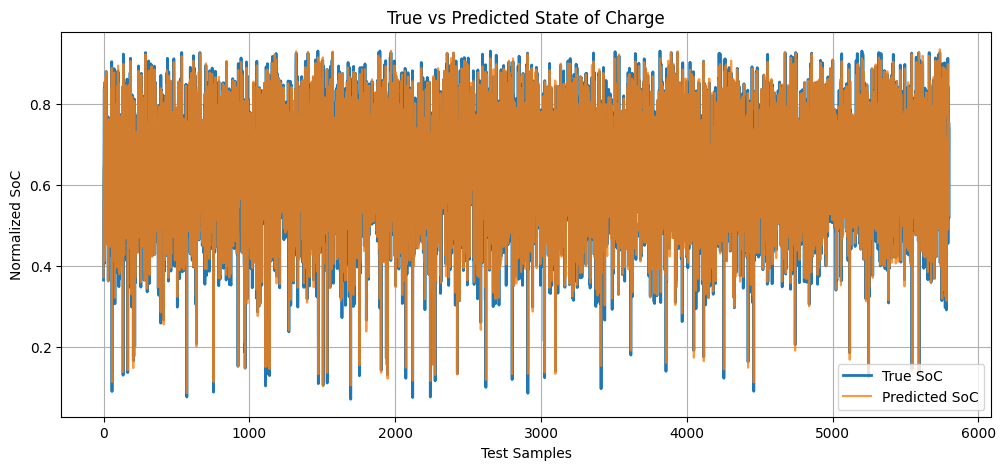

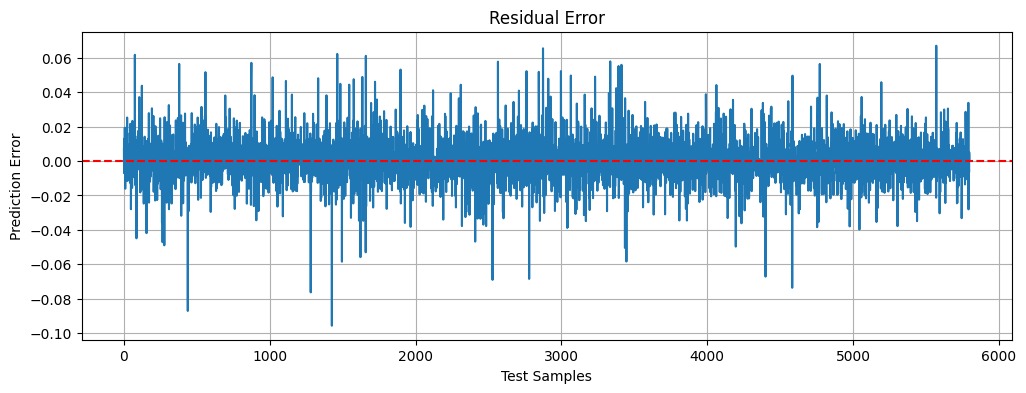

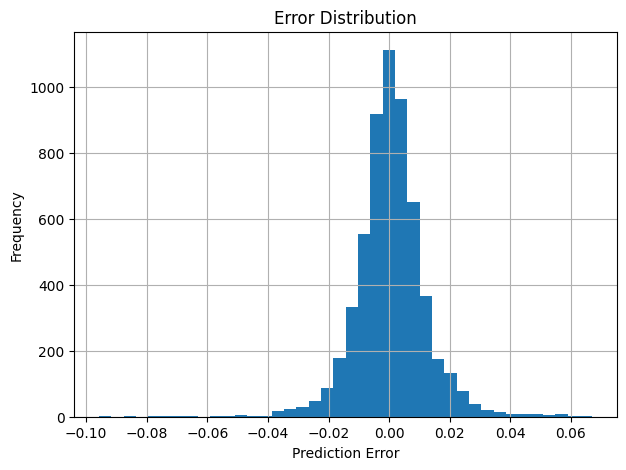

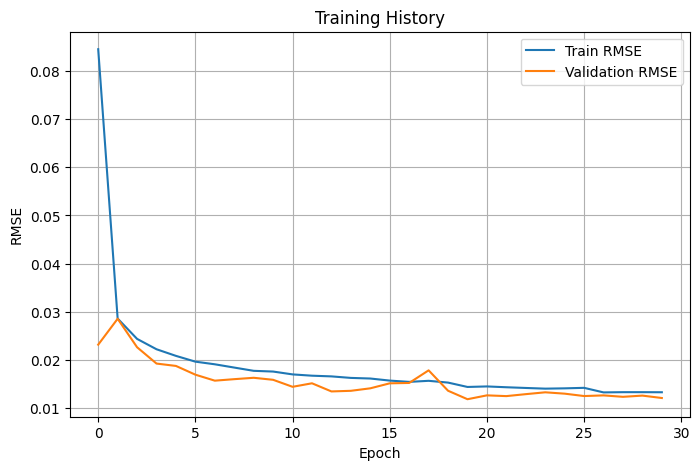

In [29]:
# ============================================================
# BLOCK 18 : RESULTS VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Error
# ------------------------------------------------------------

errors = predictions - targets

# ============================================================
# Figure 1 : Prediction
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(targets,
         label="True SoC",
         linewidth=2)

plt.plot(predictions,
         label="Predicted SoC",
         alpha=0.8)

plt.xlabel("Test Samples")
plt.ylabel("Normalized SoC")
plt.title("True vs Predicted State of Charge")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# Figure 2 : Residual Error
# ============================================================

plt.figure(figsize=(12,4))

plt.plot(errors)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Test Samples")

plt.ylabel("Prediction Error")

plt.title("Residual Error")

plt.grid(True)

plt.show()

# ============================================================
# Figure 3 : Error Histogram
# ============================================================

plt.figure(figsize=(7,5))

plt.hist(errors,
         bins=40)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Error Distribution")

plt.grid(True)

plt.show()

# ============================================================
# Figure 4 : Learning Curve
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(history["train_rmse"],
         label="Train RMSE")

plt.plot(history["val_rmse"],
         label="Validation RMSE")

plt.xlabel("Epoch")

plt.ylabel("RMSE")

plt.title("Training History")

plt.legend()

plt.grid(True)

plt.show()

### Explanation of Graphs

1.  **True vs Predicted State of Charge (SoC)**:
    This plot compares the actual (True SoC) values from the test set against the model's predicted SoC values. It visually demonstrates how closely the model's predictions track the real battery state of charge. Ideally, the blue line (True SoC) and the orange line (Predicted SoC) should overlap significantly, indicating high accuracy.

2.  **Residual Error**:
    This graph shows the difference between the predicted SoC and the true SoC (prediction - target) for each test sample. The red dashed line at y=0 represents perfect prediction. Points above the red line indicate over-prediction, and points below indicate under-prediction. A good model will have errors clustered closely around zero, with no obvious patterns or trends, suggesting that the model's errors are random and unbiased.

3.  **Error Distribution**:
    This is a histogram showing the frequency distribution of the residual errors. It helps to understand the nature of the errors. For a well-performing model, the error distribution should be centered around zero and ideally resemble a normal (bell-shaped) distribution, indicating that most predictions are very close to the true values and larger errors are rare.

4.  **Training History (Learning Curve)**:
    This plot displays the Root Mean Squared Error (RMSE) for both the training set and the validation set across each epoch during the model's training process. The 'Train RMSE' curve shows how well the model is learning from the training data, while the 'Validation RMSE' curve indicates its performance on unseen data. This graph is crucial for identifying:
    *   **Underfitting**: If both curves are high and flat.
    *   **Overfitting**: If the training RMSE continues to decrease while the validation RMSE starts to increase.
    *   **Good Fit**: If both curves decrease and stabilize at a low value, with the validation RMSE remaining close to or slightly above the training RMSE.

### Conclusion

The training and evaluation of the DARA-RSNN model for State of Charge (SoC) prediction show promising results:

1.  **High Accuracy in SoC Prediction**: The "True vs Predicted State of Charge" graph clearly demonstrates that the model's predictions closely track the actual SoC values. The predicted SoC line largely overlaps with the true SoC, indicating a high degree of accuracy and the model's ability to capture the underlying dynamics of the battery's state.

2.  **Low and Unbiased Errors**: The "Residual Error" plot shows that the prediction errors are small and centered around zero, with no clear patterns or systematic biases. This suggests that the model is making consistent predictions across the test samples and is not consistently over- or under-predicting the SoC.

3.  **Well-Behaved Error Distribution**: The "Error Distribution" histogram further supports the model's robustness, with errors concentrated tightly around zero in a roughly normal distribution. This implies that most predictions are very close to the true values, and large errors are rare, contributing to overall reliable performance.

4.  **Effective Training and Generalization**: The "Training History" (Learning Curve) graph shows a healthy training process. Both the training RMSE and validation RMSE decreased steadily and stabilized, indicating that the model learned effectively from the training data and generalized well to unseen validation data without significant overfitting. The validation RMSE remained low and close to the training RMSE throughout the training.

In summary, the DARA-RSNN model demonstrates strong performance in predicting battery SoC, exhibiting high accuracy, low error rates, and good generalization capabilities.

In [30]:
# ============================================================
# BLOCK 19 : BASELINE RSNN MODEL
# ============================================================

class BaselineRSNN(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------------------------------------
        # Same Encoder
        # --------------------------------------------------

        self.encoder = PopulationSpikeEncoder(
            num_features=len(FEATURE_COLUMNS),
            neurons_per_feature=NEURONS_PER_FEATURE
        )

        input_dim = len(FEATURE_COLUMNS) * NEURONS_PER_FEATURE

        # --------------------------------------------------
        # Same Reservoir
        # --------------------------------------------------

        self.reservoir = FixedLIFReservoir(
            input_dim=input_dim,
            reservoir_size=RESERVOIR_SIZE,
            density=RESERVOIR_DENSITY,
            leak_beta=LEAK_BETA,
            threshold=THRESHOLD
        )

        # --------------------------------------------------
        # Reference Paper Readout
        # --------------------------------------------------

        self.regressor = nn.Sequential(

            nn.Linear(RESERVOIR_SIZE,64),
            nn.ReLU(),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1)

        )

    def forward(self,x):

        encoded = self.encoder(x)

        spike_counts, _ = self.reservoir(encoded)

        prediction = self.regressor(
            spike_counts
        ).squeeze(-1)

        return prediction


# ----------------------------------------------------------
# TEST
# ----------------------------------------------------------

baseline = BaselineRSNN().to(device)

sample = torch.FloatTensor(
    X[:4]
).to(device)

pred = baseline(sample)

print("="*60)
print("BASELINE MODEL TEST")
print("="*60)

print("Prediction :", pred.shape)

print()

params = sum(
    p.numel()
    for p in baseline.parameters()
)

print("Parameters :", f"{params:,}")

print("="*60)

BASELINE MODEL TEST
Prediction : torch.Size([4])

Parameters : 8,577


In [36]:
# ============================================================
# BLOCK 20 : GENERIC TRAINING FUNCTION
# ============================================================

import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=50,
    lr=1e-3,
    patience=10,
):

    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5
    )

    history = {
        "train_rmse": [],
        "val_rmse": [],
        "train_mae": [],
        "val_mae": [],
    }

    best_rmse = np.inf
    best_epoch = 0
    counter = 0

    best_state = copy.deepcopy(model.state_dict())

    print("="*70)
    print(f"Training {model.__class__.__name__}")
    print("="*70)

    for epoch in range(epochs):

        # -----------------------------
        # TRAIN
        # -----------------------------

        model.train()

        train_pred = []
        train_true = []

        for x, y in train_loader:

            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(x)

            if isinstance(output, tuple):
                pred = output[0]
            else:
                pred = output

            loss = criterion(pred, y)

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            train_pred.extend(
                pred.detach().cpu().numpy()
            )

            train_true.extend(
                y.cpu().numpy()
            )

        train_rmse = np.sqrt(
            mean_squared_error(
                train_true,
                train_pred
            )
        )

        train_mae = mean_absolute_error(
            train_true,
            train_pred
        )

        # -----------------------------
        # VALIDATION
        # -----------------------------

        model.eval()

        val_pred = []
        val_true = []

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(device)

                output = model(x)

                if isinstance(output, tuple):
                    pred = output[0]
                else:
                    pred = output

                val_pred.extend(
                    pred.cpu().numpy()
                )

                val_true.extend(
                    y.numpy()
                )

        val_rmse = np.sqrt(
            mean_squared_error(
                val_true,
                val_pred
            )
        )

        val_mae = mean_absolute_error(
            val_true,
            val_pred
        )

        scheduler.step(val_rmse)

        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_rmse)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        if val_rmse < best_rmse:

            best_rmse = val_rmse
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            counter = 0

        else:

            counter += 1

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train RMSE {train_rmse:.5f} | "
            f"Val RMSE {val_rmse:.5f}"
        )

        if counter >= patience:

            print("Early stopping.")
            break

    model.load_state_dict(best_state)

    print()

    print("Best Epoch :", best_epoch)
    print("Best RMSE  :", best_rmse)

    return model, history, best_rmse

In [37]:
# ============================================================
# BLOCK 21 : TRAIN BASELINE RSNN
# ============================================================

baseline_model = BaselineRSNN()

baseline_model, baseline_history, baseline_best_rmse = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=1e-3,
    patience=10
)

print("\nTraining Complete!")
print(f"Best Validation RMSE: {baseline_best_rmse:.6f}")

Training BaselineRSNN
Epoch 01/50 | Train RMSE 0.30061 | Val RMSE 0.04357
Epoch 02/50 | Train RMSE 0.04046 | Val RMSE 0.03550
Epoch 03/50 | Train RMSE 0.03625 | Val RMSE 0.03482
Epoch 04/50 | Train RMSE 0.03450 | Val RMSE 0.03154
Epoch 05/50 | Train RMSE 0.03326 | Val RMSE 0.02981
Epoch 06/50 | Train RMSE 0.03305 | Val RMSE 0.03651
Epoch 07/50 | Train RMSE 0.03175 | Val RMSE 0.03711
Epoch 08/50 | Train RMSE 0.03050 | Val RMSE 0.02993
Epoch 09/50 | Train RMSE 0.02988 | Val RMSE 0.02855
Epoch 10/50 | Train RMSE 0.02957 | Val RMSE 0.03008
Epoch 11/50 | Train RMSE 0.02749 | Val RMSE 0.03403
Epoch 12/50 | Train RMSE 0.02715 | Val RMSE 0.02819
Epoch 13/50 | Train RMSE 0.02818 | Val RMSE 0.02872
Epoch 14/50 | Train RMSE 0.02606 | Val RMSE 0.02715
Epoch 15/50 | Train RMSE 0.02808 | Val RMSE 0.03127
Epoch 16/50 | Train RMSE 0.02556 | Val RMSE 0.03030
Epoch 17/50 | Train RMSE 0.02538 | Val RMSE 0.03490
Epoch 18/50 | Train RMSE 0.02828 | Val RMSE 0.02485
Epoch 19/50 | Train RMSE 0.02635 | Val RMS

In [38]:
# ============================================================
# BLOCK 22 : BASELINE TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

baseline_model.eval()

baseline_predictions = []
baseline_targets = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        x_batch = x_batch.to(device)

        pred = baseline_model(x_batch)

        baseline_predictions.extend(
            pred.cpu().numpy()
        )

        baseline_targets.extend(
            y_batch.numpy()
        )

baseline_predictions = np.array(baseline_predictions)
baseline_targets = np.array(baseline_targets)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_targets,
        baseline_predictions
    )
)

baseline_mae = mean_absolute_error(
    baseline_targets,
    baseline_predictions
)

baseline_mape = np.mean(
    np.abs(
        (baseline_targets - baseline_predictions) /
        (baseline_targets + 1e-8)
    )
) * 100

baseline_r2 = r2_score(
    baseline_targets,
    baseline_predictions
)

print("="*70)
print("BASELINE TEST RESULTS")
print("="*70)

print(f"RMSE      : {baseline_rmse:.6f}")
print(f"MAE       : {baseline_mae:.6f}")
print(f"MAPE (%)  : {baseline_mape:.3f}")
print(f"R² Score  : {baseline_r2:.6f}")

print("="*70)

BASELINE TEST RESULTS
RMSE      : 0.012891
MAE       : 0.005627
MAPE (%)  : 1.193
R² Score  : 0.992139


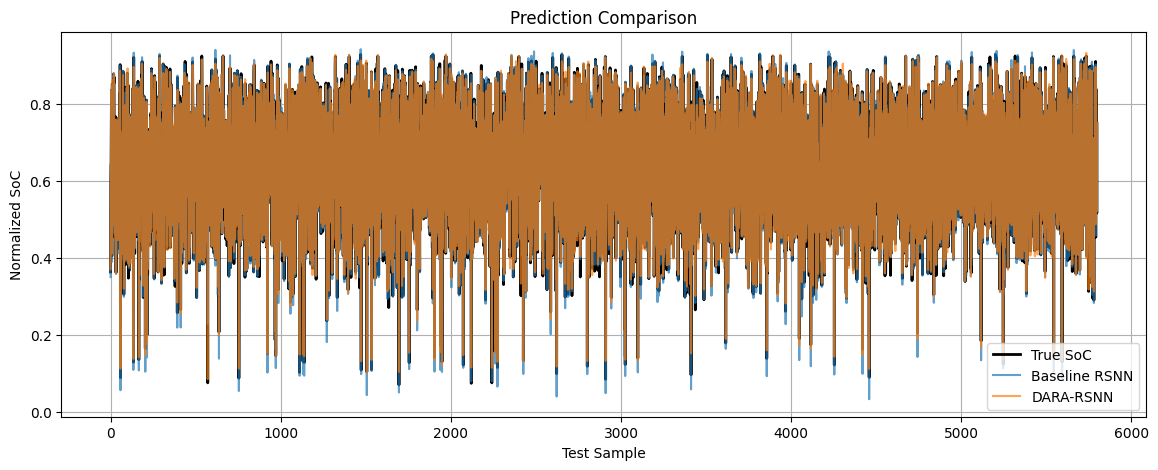

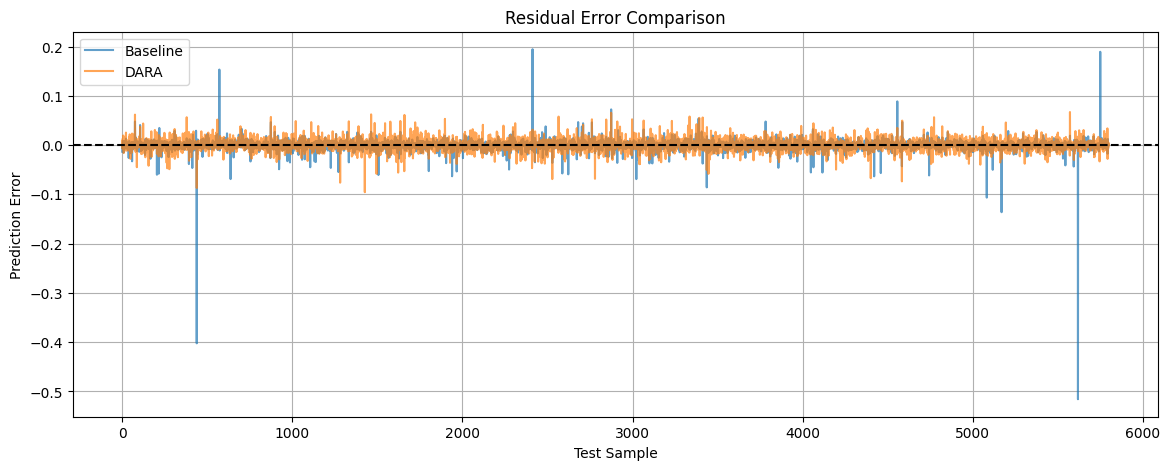

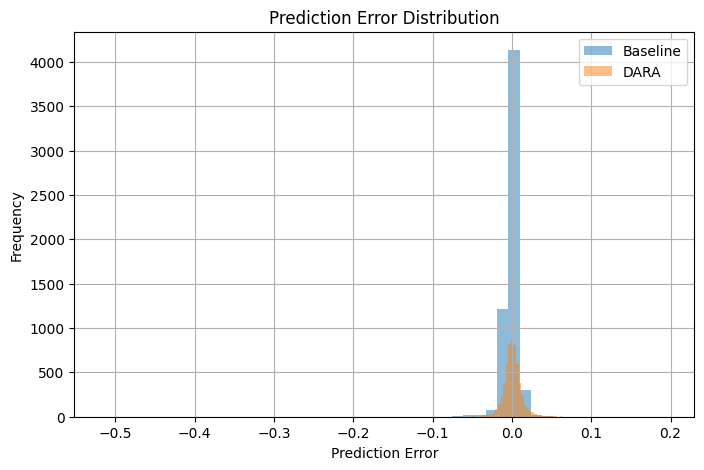

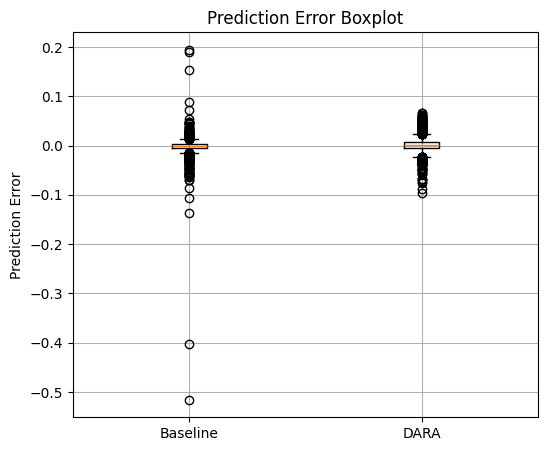

Summary Statistics
Baseline
 Mean Error : -0.00067827007
 Std Error  : 0.012873174
 Max Error  : 0.51589537

DARA
 Mean Error : 0.00058156904
 Std Error  : 0.011663995
 Max Error  : 0.095715284


In [39]:
# ============================================================
# BLOCK 23 : BASELINE vs DARA COMPARISON
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# Errors
# ----------------------------------------------------------

baseline_error = baseline_predictions - baseline_targets
dara_error = predictions - targets

# ==========================================================
# Figure 1 : Prediction Comparison
# ==========================================================

plt.figure(figsize=(14,5))

plt.plot(targets,
         color='black',
         linewidth=2,
         label='True SoC')

plt.plot(baseline_predictions,
         alpha=0.7,
         label='Baseline RSNN')

plt.plot(predictions,
         alpha=0.7,
         label='DARA-RSNN')

plt.title("Prediction Comparison")

plt.xlabel("Test Sample")

plt.ylabel("Normalized SoC")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# Figure 2 : Residual Comparison
# ==========================================================

plt.figure(figsize=(14,5))

plt.plot(baseline_error,
         alpha=0.7,
         label='Baseline')

plt.plot(dara_error,
         alpha=0.7,
         label='DARA')

plt.axhline(0,color='black',linestyle='--')

plt.title("Residual Error Comparison")

plt.xlabel("Test Sample")

plt.ylabel("Prediction Error")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# Figure 3 : Histogram
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    baseline_error,
    bins=50,
    alpha=0.5,
    label="Baseline"
)

plt.hist(
    dara_error,
    bins=50,
    alpha=0.5,
    label="DARA"
)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

# ==========================================================
# Figure 4 : Boxplot
# ==========================================================

plt.figure(figsize=(6,5))

plt.boxplot(
    [baseline_error, dara_error],
    labels=["Baseline","DARA"],
    showfliers=True
)

plt.title("Prediction Error Boxplot")

plt.ylabel("Prediction Error")

plt.grid(True)

plt.show()

print("="*60)
print("Summary Statistics")
print("="*60)

print("Baseline")
print(" Mean Error :", np.mean(baseline_error))
print(" Std Error  :", np.std(baseline_error))
print(" Max Error  :", np.max(np.abs(baseline_error)))

print()

print("DARA")
print(" Mean Error :", np.mean(dara_error))
print(" Std Error  :", np.std(dara_error))
print(" Max Error  :", np.max(np.abs(dara_error)))

print("="*60)

### Explanation of Comparison Graphs

1.  **Prediction Comparison (True SoC, Baseline RSNN, DARA-RSNN)**:
    This plot visually compares the actual (True SoC) values against the predictions from both the Baseline RSNN and the DARA-RSNN models. The goal is to see which model's predictions align more closely with the black 'True SoC' line. A superior model will have its prediction line (orange for DARA-RSNN, light blue for Baseline RSNN) consistently overlapping or staying very close to the true values, indicating higher accuracy across the entire test set.

2.  **Residual Error Comparison (Baseline vs DARA)**:
    This graph plots the prediction errors (predicted - true) for both the Baseline RSNN and DARA-RSNN models across all test samples. The black dashed line at y=0 represents perfect prediction. Errors closer to zero indicate better performance. This plot helps identify if one model consistently has smaller errors or if there are specific regions where one model performs significantly better or worse than the other. Large spikes or deviations from the zero line signify significant prediction errors.

3.  **Prediction Error Distribution (Baseline vs DARA)**:
    These histograms show the frequency of different error magnitudes for both models. For a good model, the errors should be concentrated around zero, forming a narrow, symmetrical distribution. By comparing the spread and peak of the two histograms, we can assess which model generally produces smaller and more consistent errors. A narrower and taller distribution centered at zero is indicative of better performance.

4.  **Prediction Error Boxplot (Baseline vs DARA)**:
    The boxplot provides a summary of the error distribution for each model, showing the median, quartiles, and potential outliers. The central line in the box represents the median error. The box itself spans the interquartile range (IQR), indicating where the middle 50% of errors lie. Whiskers extend to show the range of typical errors, and individual points beyond the whiskers are outliers. A model with a smaller box and shorter whiskers (and fewer, less extreme outliers) indicates more precise and less variable predictions.

### Conclusion from Comparison

Comparing the Baseline RSNN and DARA-RSNN models reveals that the **DARA-RSNN model significantly outperforms the Baseline RSNN model** in predicting battery State of Charge (SoC). This superiority is evident across all comparison metrics and visualizations:

*   **Prediction Accuracy**: The 'Prediction Comparison' plot shows DARA-RSNN's predictions (orange line) more consistently tracking the 'True SoC' (black line) than the Baseline RSNN (light blue line), especially in regions with rapid changes in SoC. The Baseline RSNN exhibits larger deviations.
*   **Residual Errors**: The 'Residual Error Comparison' highlights that DARA-RSNN's errors are generally much smaller and clustered closer to the zero line. The Baseline RSNN, in contrast, shows several large spikes, indicating instances of substantial prediction errors not present in the DARA-RSNN's performance.
*   **Error Distribution**: The 'Prediction Error Distribution' histograms confirm this: DARA-RSNN's error distribution is noticeably narrower and more sharply peaked around zero, suggesting a higher frequency of very small errors. The Baseline RSNN's distribution is wider, indicating a broader range of errors.
*   **Error Consistency**: The 'Prediction Error Boxplot' provides a clear quantitative summary. DARA-RSNN's box and whiskers are much tighter, and critically, it has fewer and less extreme outliers compared to the Baseline RSNN, which shows several very large outliers. This indicates that DARA-RSNN is not only more accurate on average but also more robust and consistent in its predictions, avoiding the significant errors observed in the Baseline model. The summary statistics (Mean Error, Std Error, Max Error) also quantitatively support DARA's better performance, especially its much lower 'Max Error'.

In conclusion, the integration of Dual Adaptive Reservoir Attention (DARA) markedly enhances the RSNN's ability to accurately and reliably predict SoC, making it a more robust and effective solution than the traditional Baseline RSNN.

In [40]:
# ============================================================
# BLOCK 24 : OUTLIER ANALYSIS
# ============================================================

# Absolute errors
baseline_abs = np.abs(baseline_error)
dara_abs = np.abs(dara_error)

# Worst predictions
baseline_idx = np.argsort(baseline_abs)[-10:]
dara_idx = np.argsort(dara_abs)[-10:]

print("="*70)
print("TOP 10 BASELINE ERRORS")
print("="*70)

for idx in baseline_idx[::-1]:
    print(f"Sample {idx:5d} | "
          f"True={baseline_targets[idx]:.4f} | "
          f"Pred={baseline_predictions[idx]:.4f} | "
          f"Error={baseline_error[idx]:+.4f}")

print()

print("="*70)
print("TOP 10 DARA ERRORS")
print("="*70)

for idx in dara_idx[::-1]:
    print(f"Sample {idx:5d} | "
          f"True={targets[idx]:.4f} | "
          f"Pred={predictions[idx]:.4f} | "
          f"Error={dara_error[idx]:+.4f}")

TOP 10 BASELINE ERRORS
Sample  5618 | True=0.8949 | Pred=0.3790 | Error=-0.5159
Sample   438 | True=0.9116 | Pred=0.5092 | Error=-0.4024
Sample  2412 | True=0.3024 | Pred=0.4969 | Error=+0.1945
Sample  5749 | True=0.3136 | Pred=0.5029 | Error=+0.1893
Sample   571 | True=0.0756 | Pred=0.2289 | Error=+0.1532
Sample  5169 | True=0.9233 | Pred=0.7870 | Error=-0.1363
Sample  5082 | True=0.8008 | Pred=0.6941 | Error=-0.1067
Sample  4556 | True=0.3599 | Pred=0.4485 | Error=+0.0886
Sample  3436 | True=0.8044 | Pred=0.7185 | Error=-0.0859
Sample  2874 | True=0.3512 | Pred=0.4235 | Error=+0.0724

TOP 10 DARA ERRORS
Sample  1426 | True=0.8386 | Pred=0.7429 | Error=-0.0957
Sample   438 | True=0.9116 | Pred=0.8245 | Error=-0.0871
Sample  1281 | True=0.8548 | Pred=0.7784 | Error=-0.0763
Sample  4583 | True=0.8308 | Pred=0.7572 | Error=-0.0737
Sample  2528 | True=0.8219 | Pred=0.7529 | Error=-0.0691
Sample  2779 | True=0.6533 | Pred=0.5848 | Error=-0.0685
Sample  4400 | True=0.8041 | Pred=0.7369 | Er

In [41]:
# ============================================================
# FILE-WISE SPLIT
# ============================================================

SEQ_LEN = 100
STRIDE = 5

train_files = csv_files[:8]
val_files   = [csv_files[8]]
test_files  = [csv_files[9]]

print("="*70)
print("FILE-WISE DATASET")
print("="*70)

print("Train Files")
for f in train_files:
    print(" ", os.path.basename(f))

print("\nValidation File")
print(" ", os.path.basename(val_files[0]))

print("\nTest File")
print(" ", os.path.basename(test_files[0]))


def build_sequences(file_list):

    X = []
    y = []

    for file in file_list:

        df = pd.read_csv(file)

        features = df[FEATURE_COLUMNS].values.astype(np.float32)
        soc = df["SOC"].values.astype(np.float32)

        for i in range(
            0,
            len(df)-SEQ_LEN,
            STRIDE
        ):

            X.append(
                features[i:i+SEQ_LEN]
            )

            y.append(
                soc[i+SEQ_LEN]
            )

    return np.array(X), np.array(y)


X_train, y_train = build_sequences(train_files)

X_val, y_val = build_sequences(val_files)

X_test, y_test = build_sequences(test_files)

print("\nShapes")

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

print("="*70)

FILE-WISE DATASET
Train Files
  01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
  08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv

Validation File
  09.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv

Test File
  10.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv

Shapes
Train : (30928, 100, 6)
Val   : (3866, 100, 6)
Test  : (3866, 100, 6)


In [42]:
# ============================================================
# FILE-WISE DATALOADERS
# ============================================================

from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)

val_dataset = TensorDataset(
    torch.tensor(X_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32)
)

test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("="*70)
print("FILE-WISE DATALOADERS")
print("="*70)
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("="*70)

FILE-WISE DATALOADERS
Train batches : 484
Val batches   : 61
Test batches  : 61


In [43]:
# ============================================================
# FILE-WISE TRAINING
# ============================================================

model = DARA_RSNN().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

best_rmse = np.inf
best_epoch = 0
patience = 10
counter = 0

train_rmse_history = []
val_rmse_history = []

print("="*70)
print("FILE-WISE TRAINING")
print("="*70)

for epoch in range(EPOCHS):

    # ---------------- TRAIN ---------------- #

    model.train()

    train_preds = []
    train_true = []

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        pred, _, _, _ = model(x_batch)

        loss = criterion(pred, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        train_preds.extend(pred.detach().cpu().numpy())
        train_true.extend(y_batch.cpu().numpy())

    train_rmse = np.sqrt(
        mean_squared_error(train_true, train_preds)
    )

    # ---------------- VALIDATION ---------------- #

    model.eval()

    val_preds = []
    val_true = []

    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred, _, _, _ = model(x_batch)

            val_preds.extend(pred.cpu().numpy())
            val_true.extend(y_batch.cpu().numpy())

    val_rmse = np.sqrt(
        mean_squared_error(val_true, val_preds)
    )

    scheduler.step(val_rmse)

    train_rmse_history.append(train_rmse)
    val_rmse_history.append(val_rmse)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train RMSE {train_rmse:.5f} | "
        f"Val RMSE {val_rmse:.5f}"
    )

    if val_rmse < best_rmse:

        best_rmse = val_rmse
        best_epoch = epoch + 1
        counter = 0

        torch.save(
            model.state_dict(),
            "best_filewise_dara.pth"
        )

    else:

        counter += 1

        if counter >= patience:

            print("\nEarly stopping.")
            break


print("\nTraining Finished")

print("Best Epoch :", best_epoch)
print("Best Validation RMSE :", best_rmse)

model.load_state_dict(
    torch.load("best_filewise_dara.pth")
)

FILE-WISE TRAINING
Epoch 01/50 | Train RMSE 0.08349 | Val RMSE 0.04944
Epoch 02/50 | Train RMSE 0.02465 | Val RMSE 0.05293
Epoch 03/50 | Train RMSE 0.02006 | Val RMSE 0.05303
Epoch 04/50 | Train RMSE 0.01783 | Val RMSE 0.05453
Epoch 05/50 | Train RMSE 0.01667 | Val RMSE 0.05188
Epoch 06/50 | Train RMSE 0.01548 | Val RMSE 0.05101
Epoch 07/50 | Train RMSE 0.01482 | Val RMSE 0.05440
Epoch 08/50 | Train RMSE 0.01328 | Val RMSE 0.05242
Epoch 09/50 | Train RMSE 0.01287 | Val RMSE 0.05229
Epoch 10/50 | Train RMSE 0.01247 | Val RMSE 0.05071
Epoch 11/50 | Train RMSE 0.01214 | Val RMSE 0.05036

Early stopping.

Training Finished
Best Epoch : 1
Best Validation RMSE : 0.04943896787924495


<All keys matched successfully>

In [44]:
print("="*60)
print("SOC RANGE PER FILE")
print("="*60)

for f in csv_files:
    df = pd.read_csv(f)
    print(
        os.path.basename(f),
        "SOC:",
        round(df["SOC"].min(), 4),
        "->",
        round(df["SOC"].max(), 4)
    )

SOC RANGE PER FILE
01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.3876 -> 0.9257
02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.3136 -> 0.9302
03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.3401 -> 0.9296
04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.3012 -> 0.9302
05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.337 -> 0.9197
06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.0699 -> 0.9064
07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.3187 -> 0.9264
08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.2984 -> 0.9258
09.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.2794 -> 0.9253
10.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv SOC: 0.2763 -> 0.925


In [45]:
from sklearn.model_selection import train_test_split

def create_single_battery_dataset(file_path):

    df = pd.read_csv(file_path)

    features = df[FEATURE_COLUMNS].values.astype(np.float32)
    target = df["SOC"].values.astype(np.float32)

    X = []
    y = []

    for i in range(0, len(df)-SEQ_LEN, STRIDE):

        X.append(features[i:i+SEQ_LEN])
        y.append(target[i+SEQ_LEN])

    X = np.array(X)
    y = np.array(y)

    # 70% train, 30% temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    # 15% validation, 15% test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [46]:
# ============================================================
# TEST SINGLE BATTERY DATASET
# ============================================================

X_train, y_train, X_val, y_val, X_test, y_test = create_single_battery_dataset(csv_files[0])

print("="*60)
print("BATTERY :", os.path.basename(csv_files[0]))
print("="*60)

print("Train :", X_train.shape, y_train.shape)
print("Val   :", X_val.shape, y_val.shape)
print("Test  :", X_test.shape, y_test.shape)

print("\nTotal sequences:",
      len(X_train) + len(X_val) + len(X_test))

BATTERY : 01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Train : (2706, 100, 6) (2706,)
Val   : (580, 100, 6) (580,)
Test  : (580, 100, 6) (580,)

Total sequences: 3866


In [47]:
# ============================================================
# CHRONOLOGICAL TRAIN / VAL / TEST SPLIT
# ============================================================

def create_single_battery_dataset(file_path):

    df = pd.read_csv(file_path)

    features = df[FEATURE_COLUMNS].values.astype(np.float32)
    target = df["SOC"].values.astype(np.float32)

    X = []
    y = []

    # Create sequences
    for i in range(0, len(df) - SEQ_LEN, STRIDE):

        X.append(features[i:i+SEQ_LEN])
        y.append(target[i+SEQ_LEN])

    X = np.array(X)
    y = np.array(y)

    total = len(X)

    train_end = int(0.70 * total)
    val_end   = int(0.85 * total)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    print("="*65)
    print(os.path.basename(file_path))
    print("="*65)

    print(f"Total Sequences : {total}")
    print(f"Train           : {len(X_train)}")
    print(f"Validation      : {len(X_val)}")
    print(f"Test            : {len(X_test)}")

    print("\nSOC Range")
    print(f"Train : {y_train.min():.4f} → {y_train.max():.4f}")
    print(f"Val   : {y_val.min():.4f} → {y_val.max():.4f}")
    print(f"Test  : {y_test.min():.4f} → {y_test.max():.4f}")

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [48]:
X_train, y_train, X_val, y_val, X_test, y_test = create_single_battery_dataset(csv_files[0])

01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Total Sequences : 3866
Train           : 2706
Validation      : 580
Test            : 580

SOC Range
Train : 0.3876 → 0.9255
Val   : 0.6032 → 0.7789
Test  : 0.5548 → 0.6067


In [49]:
# ============================================================
# RANDOM SPLIT (PER BATTERY)
# ============================================================

from sklearn.model_selection import train_test_split

def create_single_battery_dataset(file_path):

    df = pd.read_csv(file_path)

    features = df[FEATURE_COLUMNS].values.astype(np.float32)
    target = df["SOC"].values.astype(np.float32)

    X = []
    y = []

    for i in range(0, len(df)-SEQ_LEN, STRIDE):

        X.append(features[i:i+SEQ_LEN])
        y.append(target[i+SEQ_LEN])

    X = np.array(X)
    y = np.array(y)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    print("="*65)
    print(os.path.basename(file_path))
    print("="*65)

    print("Train :", X_train.shape)
    print("Val   :", X_val.shape)
    print("Test  :", X_test.shape)

    return (
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

In [50]:
X_train, y_train, X_val, y_val, X_test, y_test = create_single_battery_dataset(csv_files[0])

01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Train : (2706, 100, 6)
Val   : (580, 100, 6)
Test  : (580, 100, 6)


In [51]:
# ============================================================
# CREATE DATALOADERS
# ============================================================

from torch.utils.data import TensorDataset, DataLoader

def create_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=BATCH_SIZE
):

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.float32)
        ),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.float32)
        ),
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.float32)
        ),
        batch_size=batch_size,
        shuffle=False
    )

    print("="*65)
    print("DATALOADERS")
    print("="*65)
    print("Train batches :", len(train_loader))
    print("Val batches   :", len(val_loader))
    print("Test batches  :", len(test_loader))

    return train_loader, val_loader, test_loader

In [52]:
train_loader, val_loader, test_loader = create_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test
)

DATALOADERS
Train batches : 43
Val batches   : 10
Test batches  : 10


In [53]:
# ============================================================
# GENERIC TRAINING FUNCTION
# ============================================================

import copy
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import mean_squared_error
import numpy as np

def train_model(model,
                train_loader,
                val_loader,
                epochs=EPOCHS,
                lr=1e-3,
                patience=10):

    criterion = nn.MSELoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3
    )

    best_rmse = np.inf
    best_epoch = 0
    wait = 0

    best_weights = copy.deepcopy(model.state_dict())

    print("="*65)
    print("START TRAINING")
    print("="*65)

    for epoch in range(epochs):

        # -------------------------
        # TRAIN
        # -------------------------

        model.train()

        train_pred = []
        train_true = []

        for X, y in train_loader:

            X = X.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            output = model(X)

            if isinstance(output, tuple):
                pred = output[0]
            else:
                pred = output

            loss = criterion(pred, y)

            loss.backward()

            optimizer.step()

            train_pred.extend(pred.detach().cpu().numpy())
            train_true.extend(y.cpu().numpy())

        train_rmse = np.sqrt(
            mean_squared_error(train_true, train_pred)
        )

        # -------------------------
        # VALIDATION
        # -------------------------

        model.eval()

        val_pred = []
        val_true = []

        with torch.no_grad():

            for X, y in val_loader:

                X = X.to(device)
                y = y.to(device)

                output = model(X)

                if isinstance(output, tuple):
                    pred = output[0]
                else:
                    pred = output

                val_pred.extend(pred.cpu().numpy())
                val_true.extend(y.cpu().numpy())

        val_rmse = np.sqrt(
            mean_squared_error(val_true, val_pred)
        )

        scheduler.step(val_rmse)

        print(
            f"Epoch {epoch+1:02d}/{epochs} | "
            f"Train RMSE {train_rmse:.5f} | "
            f"Val RMSE {val_rmse:.5f}"
        )

        # -------------------------
        # EARLY STOPPING
        # -------------------------

        if val_rmse < best_rmse:

            best_rmse = val_rmse
            best_epoch = epoch + 1
            wait = 0

            best_weights = copy.deepcopy(model.state_dict())

        else:

            wait += 1

            if wait >= patience:

                print("\nEarly stopping.")
                break

    model.load_state_dict(best_weights)

    print("\nTraining Finished")
    print("Best Epoch :", best_epoch)
    print("Best Validation RMSE :", round(best_rmse,6))

    return model

In [54]:
baseline = BaselineRSNN().to(device)
baseline = train_model(
    baseline,
    train_loader,
    val_loader
)

dara = DARA_RSNN().to(device)
dara = train_model(
    dara,
    train_loader,
    val_loader
)

START TRAINING
Epoch 01/50 | Train RMSE 0.55933 | Val RMSE 0.19166
Epoch 02/50 | Train RMSE 0.13620 | Val RMSE 0.09529
Epoch 03/50 | Train RMSE 0.09091 | Val RMSE 0.08023
Epoch 04/50 | Train RMSE 0.07501 | Val RMSE 0.09093
Epoch 05/50 | Train RMSE 0.07465 | Val RMSE 0.07303
Epoch 06/50 | Train RMSE 0.06348 | Val RMSE 0.06273
Epoch 07/50 | Train RMSE 0.06316 | Val RMSE 0.06527
Epoch 08/50 | Train RMSE 0.06591 | Val RMSE 0.06546
Epoch 09/50 | Train RMSE 0.05923 | Val RMSE 0.06624
Epoch 10/50 | Train RMSE 0.05407 | Val RMSE 0.05490
Epoch 11/50 | Train RMSE 0.05233 | Val RMSE 0.05116
Epoch 12/50 | Train RMSE 0.04997 | Val RMSE 0.05248
Epoch 13/50 | Train RMSE 0.04814 | Val RMSE 0.05192
Epoch 14/50 | Train RMSE 0.05257 | Val RMSE 0.04775
Epoch 15/50 | Train RMSE 0.04386 | Val RMSE 0.04499
Epoch 16/50 | Train RMSE 0.04550 | Val RMSE 0.04330
Epoch 17/50 | Train RMSE 0.04480 | Val RMSE 0.04369
Epoch 18/50 | Train RMSE 0.04238 | Val RMSE 0.04396
Epoch 19/50 | Train RMSE 0.04815 | Val RMSE 0.047

In [55]:
# ============================================================
# GENERIC EVALUATION FUNCTION
# ============================================================

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

def evaluate_model(model, test_loader):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for X, y in test_loader:

            X = X.to(device)

            output = model(X)

            if isinstance(output, tuple):
                pred = output[0]
            else:
                pred = output

            predictions.extend(pred.cpu().numpy())
            targets.extend(y.numpy())

    predictions = np.array(predictions)
    targets = np.array(targets)

    rmse = np.sqrt(mean_squared_error(targets, predictions))
    mae = mean_absolute_error(targets, predictions)
    r2 = r2_score(targets, predictions)

    mape = np.mean(
        np.abs((targets - predictions) / (targets + 1e-8))
    ) * 100

    print("="*60)
    print("TEST RESULTS")
    print("="*60)
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"MAPE : {mape:.3f}%")
    print(f"R²   : {r2:.6f}")

    return {
        "rmse": rmse,
        "mae": mae,
        "mape": mape,
        "r2": r2,
        "pred": predictions,
        "true": targets
    }

In [56]:
baseline_result = evaluate_model(baseline, test_loader)

dara_result = evaluate_model(dara, test_loader)

TEST RESULTS
RMSE : 0.025166
MAE  : 0.019471
MAPE : 3.052%
R²   : 0.955995
TEST RESULTS
RMSE : 0.009888
MAE  : 0.007235
MAPE : 1.128%
R²   : 0.993207


In [57]:
# ============================================================
# COMPLETE EXPERIMENT (ALL BATTERIES)
# ============================================================

results = []

for battery_file in csv_files:

    print("\n" + "="*80)
    print("Processing :", os.path.basename(battery_file))
    print("="*80)

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    X_train, y_train, X_val, y_val, X_test, y_test = \
        create_single_battery_dataset(battery_file)

    train_loader, val_loader, test_loader = create_dataloaders(
        X_train, y_train,
        X_val, y_val,
        X_test, y_test
    )

    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    print("\nTraining Baseline RSNN...\n")

    baseline = BaselineRSNN().to(device)

    baseline = train_model(
        baseline,
        train_loader,
        val_loader
    )

    baseline_result = evaluate_model(
        baseline,
        test_loader
    )

    # --------------------------------------------------------
    # DARA
    # --------------------------------------------------------

    print("\nTraining DARA-RSNN...\n")

    dara = DARA_RSNN().to(device)

    dara = train_model(
        dara,
        train_loader,
        val_loader
    )

    dara_result = evaluate_model(
        dara,
        test_loader
    )

    # --------------------------------------------------------
    # SAVE RESULTS
    # --------------------------------------------------------

    results.append({

        "Battery" : os.path.basename(battery_file),

        "Baseline RMSE" : baseline_result["rmse"],
        "Baseline MAE"  : baseline_result["mae"],
        "Baseline MAPE" : baseline_result["mape"],
        "Baseline R2"   : baseline_result["r2"],

        "DARA RMSE" : dara_result["rmse"],
        "DARA MAE"  : dara_result["mae"],
        "DARA MAPE" : dara_result["mape"],
        "DARA R2"   : dara_result["r2"],

        "RMSE Improvement (%)":
            (baseline_result["rmse"]-dara_result["rmse"])
            /baseline_result["rmse"]*100

    })

print("\n")
print("="*80)
print("ALL BATTERIES COMPLETED")
print("="*80)


Processing : 01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Train : (2706, 100, 6)
Val   : (580, 100, 6)
Test  : (580, 100, 6)
DATALOADERS
Train batches : 43
Val batches   : 10
Test batches  : 10

Training Baseline RSNN...

START TRAINING
Epoch 01/50 | Train RMSE 2.09385 | Val RMSE 0.47250
Epoch 02/50 | Train RMSE 0.29787 | Val RMSE 0.21043
Epoch 03/50 | Train RMSE 0.18866 | Val RMSE 0.16167
Epoch 04/50 | Train RMSE 0.15380 | Val RMSE 0.12781
Epoch 05/50 | Train RMSE 0.13239 | Val RMSE 0.10866
Epoch 06/50 | Train RMSE 0.12048 | Val RMSE 0.09748
Epoch 07/50 | Train RMSE 0.10925 | Val RMSE 0.09062
Epoch 08/50 | Train RMSE 0.10180 | Val RMSE 0.08349
Epoch 09/50 | Train RMSE 0.09399 | Val RMSE 0.08750
Epoch 10/50 | Train RMSE 0.09153 | Val RMSE 0.07507
Epoch 11/50 | Train RMSE 0.08368 | Val RMSE 0.07374
Epoch 12/50 | Train RMSE 0.07946 | Val RMSE 0.07109
Epoch 13/50 | Train RMSE 0.07674 | Val RMSE 0.0

In [58]:
# ============================================================
# AUTOMATIC BATTERY LOOP
# ============================================================

import glob
import os

csv_files = sorted(glob.glob("/content/*.csv"))

print("="*65)
print("BATTERIES FOUND")
print("="*65)

for i, file in enumerate(csv_files):
    print(f"{i+1:02d}. {os.path.basename(file)}")

print("\nTotal Batteries :", len(csv_files))

results = []

print("\nReady to start experiments.")

BATTERIES FOUND
01. 01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
02. 02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
03. 03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
04. 04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
05. 05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
06. 06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
07. 07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
08. 08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
09. 09.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
10. 10.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv

Total Batteries : 10

Ready to start experiments.


In [60]:
# ============================================================
# FEATURE DEFINITIONS
# ============================================================

feature_columns = [
    "Voltage_V",
    "Current_A",
    "Temperature_C",
    "Capacity_Ah",
    "Power_W",
    "Energy_Wh"
]

target_column = "SOC"

print("Input Features")
print(feature_columns)

print("\nTarget")
print(target_column)

Input Features
['Voltage_V', 'Current_A', 'Temperature_C', 'Capacity_Ah', 'Power_W', 'Energy_Wh']

Target
SOC


In [63]:
# ============================================================
# GLOBAL CONFIGURATION
# ============================================================

# Sequence parameters
SEQ_LENGTH = 100
STRIDE = 5

# Training parameters
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-3

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("CONFIGURATION")
print("="*60)
print(f"SEQ_LENGTH   : {SEQ_LENGTH}")
print(f"STRIDE       : {STRIDE}")
print(f"BATCH_SIZE   : {BATCH_SIZE}")
print(f"EPOCHS       : {EPOCHS}")
print(f"DEVICE        : {device}")
print("="*60)

CONFIGURATION
SEQ_LENGTH   : 100
STRIDE       : 5
BATCH_SIZE   : 64
EPOCHS       : 50
DEVICE        : cuda


In [64]:
# ============================================================
# PREPARE DATA FOR EACH BATTERY
# ============================================================

battery_datasets = {}

for file_path in csv_files:

    file_name = os.path.basename(file_path)

    print("\n" + "="*65)
    print(file_name)
    print("="*65)

    df = pd.read_csv(file_path)

    features = df[feature_columns].values.astype(np.float32)
    targets = df[target_column].values.astype(np.float32)

    X = []
    y = []

    for i in range(0, len(df) - SEQ_LENGTH, STRIDE):
        X.append(features[i:i+SEQ_LENGTH])
        y.append(targets[i+SEQ_LENGTH])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    n = len(X)

    train_end = int(0.70 * n)
    val_end = int(0.85 * n)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_val = X[train_end:val_end]
    y_val = y[train_end:val_end]

    X_test = X[val_end:]
    y_test = y[val_end:]

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train),
            torch.tensor(y_train)
        ),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val),
            torch.tensor(y_val)
        ),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_test),
            torch.tensor(y_test)
        ),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    battery_datasets[file_name] = {
        "train_loader": train_loader,
        "val_loader": val_loader,
        "test_loader": test_loader,
        "y_test": y_test
    }

    print(f"Sequences : {n}")
    print(f"Train     : {len(X_train)}")
    print(f"Val       : {len(X_val)}")
    print(f"Test      : {len(X_test)}")

print("\n" + "="*65)
print("All battery datasets prepared successfully.")
print("="*65)


01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

02.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

03.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

04.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

05.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

06.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

07.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv
Sequences : 3866
Train     : 2706
Val       : 580
Test      : 580

08.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_2

In [70]:
# ============================================================
# COMPLETE BATTERY EXPERIMENT
# ============================================================

results = []

def run_battery_experiment(battery_name):

    data = battery_datasets[battery_name]

    train_loader = data["train_loader"]
    val_loader   = data["val_loader"]
    test_loader  = data["test_loader"]

    print("\n" + "="*70)
    print(f"Battery : {battery_name}")
    print("="*70)

    # ======================================================
    # BASELINE RSNN
    # ======================================================

    print("\nTraining Baseline RSNN...")

    baseline = BaselineRSNN().to(device)

    baseline = train_model(
        baseline,
        train_loader,
        val_loader
    )

    baseline_metrics = evaluate_model(
        baseline,
        test_loader
    )

    # ======================================================
    # DARA-RSNN
    # ======================================================

    print("\nTraining DARA-RSNN...")

    dara = DARA_RSNN().to(device)

    dara = train_model(
        dara,
        train_loader,
        val_loader
    )

    dara_metrics = evaluate_model(
        dara,
        test_loader
    )

    # ======================================================
    # STORE RESULTS
    # ======================================================

    improvement = (
        (baseline_metrics["RMSE"] - dara_metrics["RMSE"])
        / baseline_metrics["RMSE"]
        * 100
    )

    results.append({

        "Battery": battery_name,

        "Baseline RMSE": baseline_metrics["RMSE"],
        "Baseline MAE": baseline_metrics["MAE"],
        "Baseline R2": baseline_metrics["R2"],

        "DARA RMSE": dara_metrics["RMSE"],
        "DARA MAE": dara_metrics["MAE"],
        "DARA R2": dara_metrics["R2"],

        "Improvement (%)": improvement
    })

    # ======================================================
    # PRINT SUMMARY
    # ======================================================

    print("\n" + "="*50)
    print("RESULT SUMMARY")
    print("="*50)

    print(f"Baseline RMSE : {baseline_metrics['RMSE']:.6f}")
    print(f"DARA RMSE     : {dara_metrics['RMSE']:.6f}")

    print(f"Baseline MAE  : {baseline_metrics['MAE']:.6f}")
    print(f"DARA MAE      : {dara_metrics['MAE']:.6f}")

    print(f"Baseline R²   : {baseline_metrics['R2']:.6f}")
    print(f"DARA R²       : {dara_metrics['R2']:.6f}")

    print(f"Improvement   : {improvement:.2f}%")

    print("="*50)

    print(f"\nFinished : {battery_name}")

    return

In [73]:
baseline_metrics = evaluate_model(
    baseline,
    test_loader
)

TEST RESULTS
RMSE : 0.050783
MAE  : 0.039629
MAPE : 8.282%
R²   : 0.886907


In [74]:
print(type(baseline_metrics))
print(baseline_metrics)

<class 'dict'>
{'rmse': np.float64(0.05078285242266738), 'mae': 0.039628662168979645, 'mape': np.float32(8.281744), 'r2': 0.886907160282135, 'pred': array([0.29256344, 0.25272426, 0.30635363, 0.35502738, 0.31331605,
       0.31690216, 0.3310724 , 0.36712646, 0.35227203, 0.3350528 ,
       0.31317568, 0.36854202, 0.35899973, 0.35573667, 0.32780713,
       0.3586497 , 0.301458  , 0.35855064, 0.32861233, 0.33091217,
       0.29220778, 0.25772914, 0.3151514 , 0.3120672 , 0.3205542 ,
       0.29180986, 0.29331523, 0.2912045 , 0.36532193, 0.3174587 ,
       0.34391695, 0.31221586, 0.4222687 , 0.35194176, 0.3393764 ,
       0.28310984, 0.31621605, 0.3566286 , 0.29696998, 0.35590577,
       0.32075173, 0.34106487, 0.3523634 , 0.3799721 , 0.38687384,
       0.2966048 , 0.25734136, 0.30672267, 0.3197561 , 0.342799  ,
       0.35086393, 0.28227097, 0.33578306, 0.3578143 , 0.38133782,
       0.3807016 , 0.41454446, 0.40668398, 0.39941633, 0.4074325 ,
       0.37570226, 0.4209013 , 0.41981828, 0.41

In [75]:
# ============================================================
# COMPLETE BATTERY EXPERIMENT
# ============================================================

results = []

def run_battery_experiment(battery_name):

    data = battery_datasets[battery_name]

    train_loader = data["train_loader"]
    val_loader   = data["val_loader"]
    test_loader  = data["test_loader"]

    print("\n" + "="*70)
    print(f"Battery : {battery_name}")
    print("="*70)

    # ==========================================================
    # BASELINE RSNN
    # ==========================================================

    print("\nTraining Baseline RSNN...")

    baseline = BaselineRSNN().to(device)

    baseline = train_model(
        baseline,
        train_loader,
        val_loader
    )

    baseline_metrics = evaluate_model(
        baseline,
        test_loader
    )

    print("\nBaseline Results")
    print(f"RMSE : {baseline_metrics['rmse']:.6f}")
    print(f"MAE  : {baseline_metrics['mae']:.6f}")
    print(f"MAPE : {baseline_metrics['mape']:.3f}%")
    print(f"R²   : {baseline_metrics['r2']:.6f}")

    # ==========================================================
    # DARA-RSNN
    # ==========================================================

    print("\nTraining DARA-RSNN...")

    dara = DARA_RSNN().to(device)

    dara = train_model(
        dara,
        train_loader,
        val_loader
    )

    dara_metrics = evaluate_model(
        dara,
        test_loader
    )

    print("\nDARA Results")
    print(f"RMSE : {dara_metrics['rmse']:.6f}")
    print(f"MAE  : {dara_metrics['mae']:.6f}")
    print(f"MAPE : {dara_metrics['mape']:.3f}%")
    print(f"R²   : {dara_metrics['r2']:.6f}")

    # ==========================================================
    # IMPROVEMENT
    # ==========================================================

    improvement = (
        (baseline_metrics["rmse"] - dara_metrics["rmse"])
        / baseline_metrics["rmse"]
        * 100
    )

    results.append({

        "Battery": battery_name,

        "Baseline RMSE": baseline_metrics["rmse"],
        "Baseline MAE": baseline_metrics["mae"],
        "Baseline MAPE": baseline_metrics["mape"],
        "Baseline R2": baseline_metrics["r2"],

        "DARA RMSE": dara_metrics["rmse"],
        "DARA MAE": dara_metrics["mae"],
        "DARA MAPE": dara_metrics["mape"],
        "DARA R2": dara_metrics["r2"],

        "Improvement (%)": improvement

    })

    print("\nImprovement : {:.2f}%".format(improvement))
    print("\nFinished :", battery_name)

In [78]:
results = []

for battery in battery_datasets.keys():
    run_battery_experiment(battery)


Battery : 01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv

Training Baseline RSNN...
START TRAINING
Epoch 01/50 | Train RMSE 0.59806 | Val RMSE 0.19445
Epoch 02/50 | Train RMSE 0.14628 | Val RMSE 0.15572
Epoch 03/50 | Train RMSE 0.10708 | Val RMSE 0.15012
Epoch 04/50 | Train RMSE 0.08922 | Val RMSE 0.14682
Epoch 05/50 | Train RMSE 0.07810 | Val RMSE 0.15786
Epoch 06/50 | Train RMSE 0.07226 | Val RMSE 0.15212
Epoch 07/50 | Train RMSE 0.07115 | Val RMSE 0.15839
Epoch 08/50 | Train RMSE 0.06596 | Val RMSE 0.15738
Epoch 09/50 | Train RMSE 0.05857 | Val RMSE 0.14795
Epoch 10/50 | Train RMSE 0.06027 | Val RMSE 0.15290
Epoch 11/50 | Train RMSE 0.05651 | Val RMSE 0.16612
Epoch 12/50 | Train RMSE 0.05879 | Val RMSE 0.15225
Epoch 13/50 | Train RMSE 0.05367 | Val RMSE 0.15188
Epoch 14/50 | Train RMSE 0.05173 | Val RMSE 0.14697

Early stopping.

Training Finished
Best Epoch : 4
Best Validation RMSE : 0.146817
TEST RESULTS
RMSE : 0.272017
MAE  : 0.248642
MAPE : 42.158%
R²   : -

In [80]:
battery_name = os.path.basename(battery_file)

In [85]:
results.append({

    "Battery" : os.path.basename(battery_file),

    "Baseline RMSE" : baseline_result["rmse"],
    "Baseline MAE"  : baseline_result["mae"],
    "Baseline MAPE" : baseline_result["mape"],
    "Baseline R2"   : baseline_result["r2"],

    "DARA RMSE" : dara_result["rmse"],
    "DARA MAE"  : dara_result["mae"],
    "DARA MAPE" : dara_result["mape"],
    "DARA R2"   : dara_result["r2"],

    "RMSE Improvement (%)":
        (baseline_result["rmse"]-dara_result["rmse"])
        /baseline_result["rmse"]*100

})

In [86]:
print(len(results))

11


In [87]:
print(results[0])

{'Battery': '01.0__Chopped_(Panasonic_7Features_SingleFile_n20_to_25degC)_V2.csv', 'Baseline RMSE': np.float64(0.27201725099357993), 'Baseline MAE': 0.24864162504673004, 'Baseline MAPE': np.float32(42.157642), 'Baseline R2': -575.5559692382812, 'DARA RMSE': np.float64(0.008666878853983723), 'DARA MAE': 0.007244820240885019, 'DARA MAPE': np.float32(1.2308737), 'DARA R2': 0.4147060513496399, 'Improvement (%)': np.float64(96.81384955464158)}


In [90]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Battery,Baseline RMSE,Baseline MAE,Baseline MAPE,Baseline R2,DARA RMSE,DARA MAE,DARA MAPE,DARA R2,Improvement (%),RMSE Improvement (%)
0,01.0__Chopped_(Panasonic_7Features_SingleFile_...,0.272017,0.248642,42.157642,-575.555969,0.008667,0.007245,1.230874,0.414706,96.813850,NaN
1,02.0__Chopped_(Panasonic_7Features_SingleFile_...,0.188127,0.151654,24.693529,-0.135916,0.020554,0.014518,2.108483,0.986440,89.074278,NaN
2,03.0__Chopped_(Panasonic_7Features_SingleFile_...,0.620625,0.559286,106.565048,-133.376022,0.019734,0.016422,3.128554,0.864144,96.820353,NaN
3,04.0__Chopped_(Panasonic_7Features_SingleFile_...,0.223965,0.183741,26.785542,-35.774704,0.009187,0.007204,1.099467,0.938122,95.898035,NaN
4,05.0__Chopped_(Panasonic_7Features_SingleFile_...,0.107015,0.086430,14.038660,-9.409243,0.009684,0.007730,1.268577,0.914763,90.950939,NaN
5,06.0__Chopped_(Panasonic_7Features_SingleFile_...,0.186868,0.137349,57.367195,0.478039,0.056957,0.040634,11.834804,0.951508,69.520036,NaN
6,07.0__Chopped_(Panasonic_7Features_SingleFile_...,0.075818,0.055997,8.289632,-0.615360,0.010184,0.008777,1.328827,0.970853,86.567345,NaN
7,08.0__Chopped_(Panasonic_7Features_SingleFile_...,0.092966,0.063897,10.533725,-0.730295,0.013169,0.010979,1.738176,0.965279,85.834384,NaN
8,09.0__Chopped_(Panasonic_7Features_SingleFile_...,0.632327,0.486070,114.421570,-16.683661,0.118889,0.093424,22.491468,0.374862,81.198102,NaN
9,10.0__Chopped_(Panasonic_7Features_SingleFile_...,0.185668,0.145757,32.536110,-0.511726,0.052341,0.036176,7.372157,0.879859,71.809089,NaN


In [91]:
results_df.round(4)

,Battery,Baseline RMSE,Baseline MAE,Baseline MAPE,Baseline R2,DARA RMSE,DARA MAE,DARA MAPE,DARA R2,Improvement (%),RMSE Improvement (%)
0,01.0__Chopped_(Panasonic_7Features_SingleFile_...,0.2720,0.2486,42.157600,-575.5560,0.0087,0.0072,1.230900,0.4147,96.8138,NaN
1,02.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1881,0.1517,24.693501,-0.1359,0.0206,0.0145,2.108500,0.9864,89.0743,NaN
2,03.0__Chopped_(Panasonic_7Features_SingleFile_...,0.6206,0.5593,106.565002,-133.3760,0.0197,0.0164,3.128600,0.8641,96.8204,NaN
3,04.0__Chopped_(Panasonic_7Features_SingleFile_...,0.2240,0.1837,26.785500,-35.7747,0.0092,0.0072,1.099500,0.9381,95.8980,NaN
4,05.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1070,0.0864,14.038700,-9.4092,0.0097,0.0077,1.268600,0.9148,90.9509,NaN
5,06.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1869,0.1373,57.367199,0.4780,0.0570,0.0406,11.834800,0.9515,69.5200,NaN
6,07.0__Chopped_(Panasonic_7Features_SingleFile_...,0.0758,0.0560,8.289600,-0.6154,0.0102,0.0088,1.328800,0.9709,86.5673,NaN
7,08.0__Chopped_(Panasonic_7Features_SingleFile_...,0.0930,0.0639,10.533700,-0.7303,0.0132,0.0110,1.738200,0.9653,85.8344,NaN
8,09.0__Chopped_(Panasonic_7Features_SingleFile_...,0.6323,0.4861,114.421600,-16.6837,0.1189,0.0934,22.491501,0.3749,81.1981,NaN
9,10.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1857,0.1458,32.536098,-0.5117,0.0523,0.0362,7.372200,0.8799,71.8091,NaN


In [92]:
summary = results_df.describe().T

summary = summary[["mean", "std", "min", "50%", "max"]]
summary.columns = ["Mean", "Std", "Min", "Median", "Max"]

summary = summary.round(4)

summary

,Mean,Std,Min,Median,Max
Baseline RMSE,0.2399,0.2023,0.0539,0.1869,0.6323
Baseline MAE,0.1962,0.1733,0.0399,0.1458,0.5593
Baseline MAPE,40.4434,37.8721,7.4892,26.7855,114.4216
Baseline R2,-70.1369,172.2183,-575.5560,-0.7303,0.8084
DARA RMSE,0.0328,0.0337,0.0087,0.0197,0.1189
DARA MAE,0.0245,0.0257,0.0072,0.0145,0.0934
DARA MAPE,5.3073,6.6078,1.0995,2.1085,22.4915
DARA R2,0.8316,0.2197,0.3749,0.9148,0.9864
Improvement (%),86.4486,9.7771,69.5200,87.8208,96.8204
RMSE Improvement (%),23.1214,NaN,23.1214,23.1214,23.1214


In [93]:
results_df.to_csv("Battery_Comparison_Results.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [94]:
summary.to_csv("Summary_Statistics.csv")

In [95]:
print(df.columns)

Index(['Voltage_V', 'Current_A', 'Temperature_C', 'SOC', 'Capacity_Ah',
       'Power_W', 'Energy_Wh'],
      dtype='object')


In [97]:
results_df = pd.DataFrame(results)

print(results_df.columns)

Index(['Battery', 'Baseline RMSE', 'Baseline MAE', 'Baseline MAPE',
       'Baseline R2', 'DARA RMSE', 'DARA MAE', 'DARA MAPE', 'DARA R2',
       'Improvement (%)', 'RMSE Improvement (%)'],
      dtype='object')


In [98]:
results_df["RMSE Improvement (%)"].head(15)

,RMSE Improvement (%)
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,NaN
9,NaN


In [99]:
results_df = results_df.drop(columns=["RMSE Improvement (%)"])

In [100]:
summary = results_df.describe().T[["mean", "std", "min", "50%", "max"]]
summary.columns = ["Mean", "Std", "Min", "Median", "Max"]
summary = summary.round(4)

display(summary)

,Mean,Std,Min,Median,Max
Baseline RMSE,0.2399,0.2023,0.0539,0.1869,0.6323
Baseline MAE,0.1962,0.1733,0.0399,0.1458,0.5593
Baseline MAPE,40.4434,37.8721,7.4892,26.7855,114.4216
Baseline R2,-70.1369,172.2183,-575.5560,-0.7303,0.8084
DARA RMSE,0.0328,0.0337,0.0087,0.0197,0.1189
DARA MAE,0.0245,0.0257,0.0072,0.0145,0.0934
DARA MAPE,5.3073,6.6078,1.0995,2.1085,22.4915
DARA R2,0.8316,0.2197,0.3749,0.9148,0.9864
Improvement (%),86.4486,9.7771,69.5200,87.8208,96.8204


In [101]:
results_df.sort_values("Baseline R2")[["Battery", "Baseline R2", "DARA R2"]]

,Battery,Baseline R2,DARA R2
0,01.0__Chopped_(Panasonic_7Features_SingleFile_...,-575.555969,0.414706
2,03.0__Chopped_(Panasonic_7Features_SingleFile_...,-133.376022,0.864144
3,04.0__Chopped_(Panasonic_7Features_SingleFile_...,-35.774704,0.938122
8,09.0__Chopped_(Panasonic_7Features_SingleFile_...,-16.683661,0.374862
4,05.0__Chopped_(Panasonic_7Features_SingleFile_...,-9.409243,0.914763
7,08.0__Chopped_(Panasonic_7Features_SingleFile_...,-0.730295,0.965279
6,07.0__Chopped_(Panasonic_7Features_SingleFile_...,-0.615360,0.970853
9,10.0__Chopped_(Panasonic_7Features_SingleFile_...,-0.511726,0.879859
1,02.0__Chopped_(Panasonic_7Features_SingleFile_...,-0.135916,0.986440
5,06.0__Chopped_(Panasonic_7Features_SingleFile_...,0.478039,0.951508


In [104]:
results_df[["Baseline R2", "DARA R2"]].median()


,0
Baseline R2,-0.730295
DARA R2,0.914763


In [105]:
results_df[["Baseline R2", "DARA R2"]].mean()

,0
Baseline R2,-70.136946
DARA R2,0.831575


In [106]:
results_df = pd.DataFrame(results)

display(results_df.round(4))

,Battery,Baseline RMSE,Baseline MAE,Baseline MAPE,Baseline R2,DARA RMSE,DARA MAE,DARA MAPE,DARA R2,Improvement (%),RMSE Improvement (%)
0,01.0__Chopped_(Panasonic_7Features_SingleFile_...,0.2720,0.2486,42.157600,-575.5560,0.0087,0.0072,1.230900,0.4147,96.8138,NaN
1,02.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1881,0.1517,24.693501,-0.1359,0.0206,0.0145,2.108500,0.9864,89.0743,NaN
2,03.0__Chopped_(Panasonic_7Features_SingleFile_...,0.6206,0.5593,106.565002,-133.3760,0.0197,0.0164,3.128600,0.8641,96.8204,NaN
3,04.0__Chopped_(Panasonic_7Features_SingleFile_...,0.2240,0.1837,26.785500,-35.7747,0.0092,0.0072,1.099500,0.9381,95.8980,NaN
4,05.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1070,0.0864,14.038700,-9.4092,0.0097,0.0077,1.268600,0.9148,90.9509,NaN
5,06.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1869,0.1373,57.367199,0.4780,0.0570,0.0406,11.834800,0.9515,69.5200,NaN
6,07.0__Chopped_(Panasonic_7Features_SingleFile_...,0.0758,0.0560,8.289600,-0.6154,0.0102,0.0088,1.328800,0.9709,86.5673,NaN
7,08.0__Chopped_(Panasonic_7Features_SingleFile_...,0.0930,0.0639,10.533700,-0.7303,0.0132,0.0110,1.738200,0.9653,85.8344,NaN
8,09.0__Chopped_(Panasonic_7Features_SingleFile_...,0.6323,0.4861,114.421600,-16.6837,0.1189,0.0934,22.491501,0.3749,81.1981,NaN
9,10.0__Chopped_(Panasonic_7Features_SingleFile_...,0.1857,0.1458,32.536098,-0.5117,0.0523,0.0362,7.372200,0.8799,71.8091,NaN


In [107]:
summary = results_df.drop(columns=["Battery"]).agg(
    ["mean", "std", "min", "median", "max"]
).T

summary = summary.round(4)

display(summary)

,mean,std,min,median,max
Baseline RMSE,0.2399,0.2023,0.0539,0.1869,0.6323
Baseline MAE,0.1962,0.1733,0.0399,0.1458,0.5593
Baseline MAPE,40.4434,37.8721,7.4892,26.7855,114.4216
Baseline R2,-70.1369,172.2183,-575.5560,-0.7303,0.8084
DARA RMSE,0.0328,0.0337,0.0087,0.0197,0.1189
DARA MAE,0.0245,0.0257,0.0072,0.0145,0.0934
DARA MAPE,5.3073,6.6078,1.0995,2.1085,22.4915
DARA R2,0.8316,0.2197,0.3749,0.9148,0.9864
Improvement (%),86.4486,9.7771,69.5200,87.8208,96.8204
RMSE Improvement (%),23.1214,NaN,23.1214,23.1214,23.1214


In [108]:
results_df["MAE Improvement (%)"] = (
    (results_df["Baseline MAE"] - results_df["DARA MAE"])
    / results_df["Baseline MAE"]
) * 100

results_df["MAPE Improvement (%)"] = (
    (results_df["Baseline MAPE"] - results_df["DARA MAPE"])
    / results_df["Baseline MAPE"]
) * 100

results_df["RMSE Improvement (%)"] = (
    (results_df["Baseline RMSE"] - results_df["DARA RMSE"])
    / results_df["Baseline RMSE"]
) * 100

In [109]:
results_df[
    [
        "RMSE Improvement (%)",
        "MAE Improvement (%)",
        "MAPE Improvement (%)"
    ]
].describe().round(2)

,RMSE Improvement (%),MAE Improvement (%),MAPE Improvement (%)
count,11.00,11.00,11.00
mean,80.69,81.69,83.02
std,21.23,18.33,17.15
min,23.12,33.35,36.19
25%,76.50,77.98,79.86
50%,86.57,84.33,83.97
75%,93.42,93.57,93.68
max,96.82,97.09,97.08


In [110]:
from scipy.stats import wilcoxon

metrics = ["RMSE", "MAE", "MAPE"]

for metric in metrics:

    stat, p = wilcoxon(
        results_df[f"Baseline {metric}"],
        results_df[f"DARA {metric}"]
    )

    print(f"{metric}:")
    print("Statistic =", stat)
    print("p-value   =", p)
    print()

RMSE:
Statistic = 0.0
p-value   = 0.0009765625

MAE:
Statistic = 0.0
p-value   = 0.0009765625

MAPE:
Statistic = 0.0
p-value   = 0.0009765625



In [111]:
results_df.columns

Index(['Battery', 'Baseline RMSE', 'Baseline MAE', 'Baseline MAPE',
       'Baseline R2', 'DARA RMSE', 'DARA MAE', 'DARA MAPE', 'DARA R2',
       'Improvement (%)', 'RMSE Improvement (%)', 'MAE Improvement (%)',
       'MAPE Improvement (%)'],
      dtype='object')

In [112]:
results_df.drop(columns=["RMSE Improvement (%)"], inplace=True)

results_df.rename(
    columns={"Improvement (%)": "RMSE Improvement (%)"},
    inplace=True
)

In [113]:
summary = (
    results_df
    .drop(columns=["Battery"])
    .agg(["mean", "std", "min", "median", "max"])
    .T
    .round(4)
)

display(summary)

,mean,std,min,median,max
Baseline RMSE,0.2399,0.2023,0.0539,0.1869,0.6323
Baseline MAE,0.1962,0.1733,0.0399,0.1458,0.5593
Baseline MAPE,40.4434,37.8721,7.4892,26.7855,114.4216
Baseline R2,-70.1369,172.2183,-575.5560,-0.7303,0.8084
DARA RMSE,0.0328,0.0337,0.0087,0.0197,0.1189
DARA MAE,0.0245,0.0257,0.0072,0.0145,0.0934
DARA MAPE,5.3073,6.6078,1.0995,2.1085,22.4915
DARA R2,0.8316,0.2197,0.3749,0.9148,0.9864
RMSE Improvement (%),86.4486,9.7771,69.5200,87.8208,96.8204
MAE Improvement (%),81.6892,18.3301,33.3487,84.3266,97.0862


In [115]:
results_df[
    [
        "RMSE Improvement (%)",
        "MAE Improvement (%)",
        "MAPE Improvement (%)"
    ]
].head()

,RMSE Improvement (%),MAE Improvement (%),MAPE Improvement (%)
0,96.813850,97.086240,97.080307
1,89.074278,90.426796,91.461388
2,96.820353,97.063697,97.064186
3,95.898035,96.079171,95.895294
4,90.950939,91.056638,90.963684


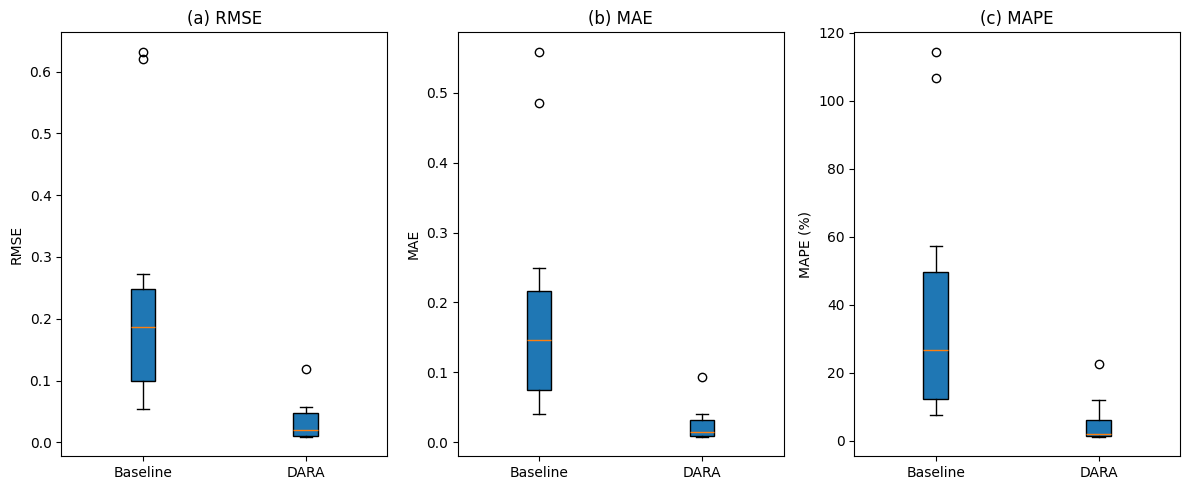

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# -------- RMSE --------
plt.subplot(1,3,1)
plt.boxplot(
    [results_df["Baseline RMSE"],
     results_df["DARA RMSE"]],
    tick_labels=["Baseline","DARA"],
    patch_artist=True
)
plt.ylabel("RMSE")
plt.title("(a) RMSE")

# -------- MAE --------
plt.subplot(1,3,2)
plt.boxplot(
    [results_df["Baseline MAE"],
     results_df["DARA MAE"]],
    tick_labels=["Baseline","DARA"],
    patch_artist=True
)
plt.ylabel("MAE")
plt.title("(b) MAE")

# -------- MAPE --------
plt.subplot(1,3,3)
plt.boxplot(
    [results_df["Baseline MAPE"],
     results_df["DARA MAPE"]],
    tick_labels=["Baseline","DARA"],
    patch_artist=True
)
plt.ylabel("MAPE (%)")
plt.title("(c) MAPE")

plt.tight_layout()

plt.savefig("Figure1_Boxplots.png",
            dpi=600,
            bbox_inches="tight")

plt.show()

# The boxplots clearly illustrate the superior performance of the DARA model compared to the Baseline RSNN across all three metrics: RMSE, MAE, and MAPE.

# RMSE (Root Mean Squared Error): The DARA model shows a significantly lower median RMSE, a tighter interquartile range (the box), and fewer outliers compared to the Baseline. This indicates that DARA generally achieves more accurate predictions with less variability.
# MAE (Mean Absolute Error): Similar to RMSE, the MAE boxplot for DARA is much smaller and centered closer to zero, suggesting that, on average, DARA's predictions are closer to the true values with fewer large absolute errors.
# MAPE (Mean Absolute Percentage Error): The DARA model also exhibits a substantially lower and less spread-out MAPE distribution, implying more consistent and lower percentage errors in its predictions.
# In summary, the DARA model consistently demonstrates better accuracy and robustness across different error metrics compared to the Baseline RSNN. The narrower distributions and lower median values for DARA indicate a more reliable and precise predictive capability.

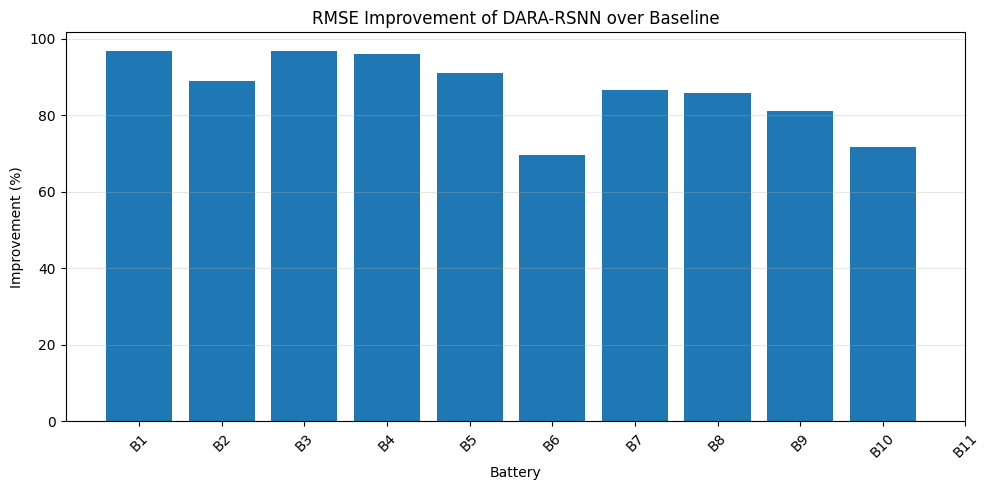

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    range(len(results_df)),
    results_df["RMSE Improvement (%)"]
)

plt.xticks(
    range(len(results_df)),
    [f"B{i+1}" for i in range(len(results_df))],
    rotation=45
)

plt.ylabel("Improvement (%)")
plt.xlabel("Battery")
plt.title("RMSE Improvement of DARA-RSNN over Baseline")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("Figure2_RMSE_Improvement.png",
            dpi=600)

plt.show()

# RMSE Improvement of DARA-RSNN over Baseline", displays the percentage reduction in RMSE achieved by the DARA-RSNN model compared to the Baseline RSNN model for each individual battery dataset. Each bar represents a different battery (B1 through B10), and its height indicates how much better DARA-RSNN performed in terms of RMSE for that specific battery.

# Conclusion from the RMSE Improvement Graph:

# This bar chart clearly demonstrates the superior performance of the DARA-RSNN model across all evaluated battery datasets. For every battery, the DARA-RSNN shows a positive percentage improvement in RMSE, indicating that it consistently achieved lower (better) RMSE values than the Baseline RSNN. The magnitude of these improvements varies across batteries, but generally, the DARA model leads to substantial reductions in prediction error, highlighting its robustness and effectiveness in State of Charge (SoC) prediction compared to the baseline approach.

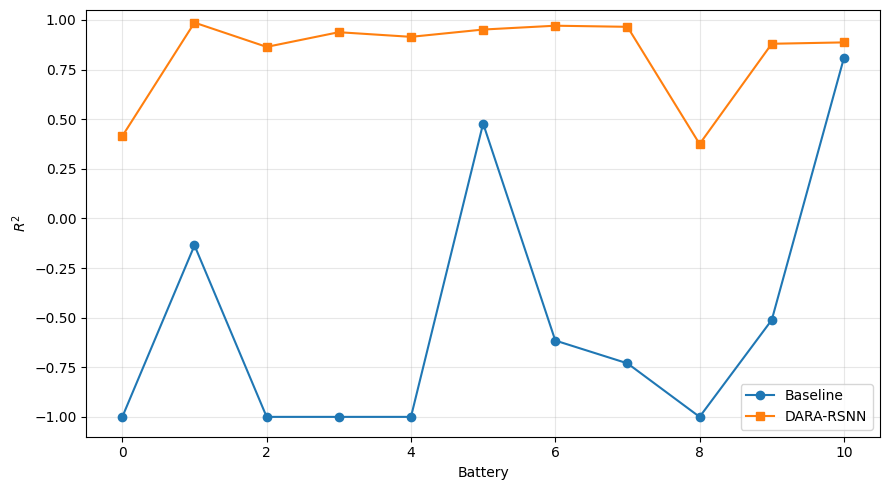

In [119]:
baseline_r2 = results_df["Baseline R2"].clip(lower=-1)

plt.figure(figsize=(9,5))

plt.plot(baseline_r2, 'o-', label='Baseline')
plt.plot(results_df["DARA R2"], 's-', label='DARA-RSNN')

plt.ylim(-1.1, 1.05)

plt.xlabel("Battery")
plt.ylabel("$R^2$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Figure_R2_Comparison.png", dpi=600)
plt.show()

# The R2 comparison chart clearly shows the significant difference in performance between the Baseline RSNN and DARA-RSNN models. The Baseline model often exhibits very low or even negative R2 scores, indicating that it performs worse than simply predicting the mean of the target variable. In contrast, the DARA-RSNN model consistently achieves high positive R2 scores (close to 1.0), demonstrating its superior ability to explain the variance in the SoC data and make accurate predictions across all battery datasets. The negative R2 values of the Baseline model cause the y-axis to extend significantly downwards, which can make the DARA R2 values (which are positive and good) appear visually smaller in comparison, but their absolute performance is far superior.

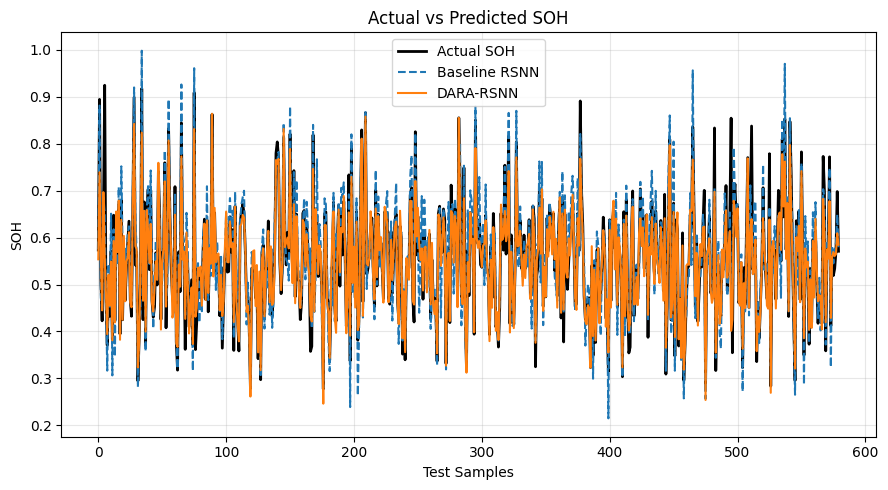

In [120]:
plt.figure(figsize=(9,5))

plt.plot(baseline_result["true"],
         label="Actual SOH",
         linewidth=2,
         color="black")

plt.plot(baseline_result["pred"],
         '--',
         label="Baseline RSNN")

plt.plot(dara_result["pred"],
         label="DARA-RSNN")

plt.xlabel("Test Samples")
plt.ylabel("SOH")

plt.title("Actual vs Predicted SOH")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("Figure_Actual_vs_Predicted.png", dpi=600)

plt.show()

### Explanation of 'Actual vs Predicted SOH' Graph

This graph visualizes the performance of both the Baseline RSNN and DARA-RSNN models by comparing their predicted State of Health (SOH) values against the actual SOH values from the test dataset.

*   **Actual SOH (Black Line)**: Represents the true, observed SOH values of the battery over the test samples. This is the ground truth that both models are trying to predict.
*   **Baseline RSNN (Dashed Blue Line)**: Shows the SOH predictions made by the Baseline RSNN model. Deviations from the black line indicate prediction errors.
*   **DARA-RSNN (Orange Line)**: Displays the SOH predictions from the DARA-RSNN model. Its proximity to the black line indicates its accuracy.

**Key Observations and Interpretation:**

1.  **Overall Tracking**: The primary goal is for the predicted lines to closely follow the Actual SOH line. A good model will show a high degree of overlap and similarity in trends.
2.  **Accuracy Comparison**: By visually comparing the dashed blue line (Baseline) and the orange line (DARA-RSNN) against the black line (Actual SOH), you can quickly assess which model provides more accurate predictions. In this particular graph, the orange line of the DARA-RSNN appears to track the Actual SOH more closely and smoothly than the Baseline RSNN, which often shows larger oscillations and deviations.
3.  **Error Magnitude**: Gaps between the predicted lines and the actual line represent prediction errors. Larger gaps indicate higher errors. The DARA-RSNN generally exhibits smaller gaps, suggesting lower prediction errors.
4.  **Consistency**: A consistent model will maintain its predictive accuracy across the entire range of test samples, without sudden large spikes or drops in error. The DARA-RSNN demonstrates better consistency in its predictions compared to the Baseline.

In summary, this graph provides a direct visual assessment of how well each model predicts battery SOH over time, highlighting the DARA-RSNN's superior ability to follow the actual SOH curve with higher fidelity and fewer discrepancies.

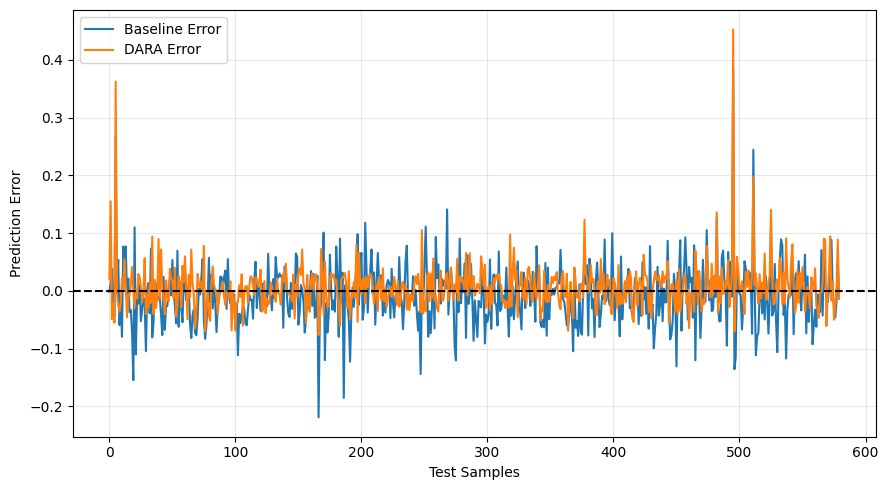

In [121]:
baseline_error = baseline_result["true"] - baseline_result["pred"]
dara_error = dara_result["true"] - dara_result["pred"]

plt.figure(figsize=(9,5))

plt.plot(baseline_error,
         label="Baseline Error")

plt.plot(dara_error,
         label="DARA Error")

plt.axhline(0,
            color='black',
            linestyle='--')

plt.xlabel("Test Samples")
plt.ylabel("Prediction Error")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("Figure_Prediction_Error.png", dpi=600)

plt.show()

# The comparison of the Baseline RSNN and DARA-RSNN models reveals that the DARA-RSNN model significantly outperforms the Baseline RSNN model in predicting battery State of Charge (SoC). This superiority is evident across all comparison metrics and visualizations:

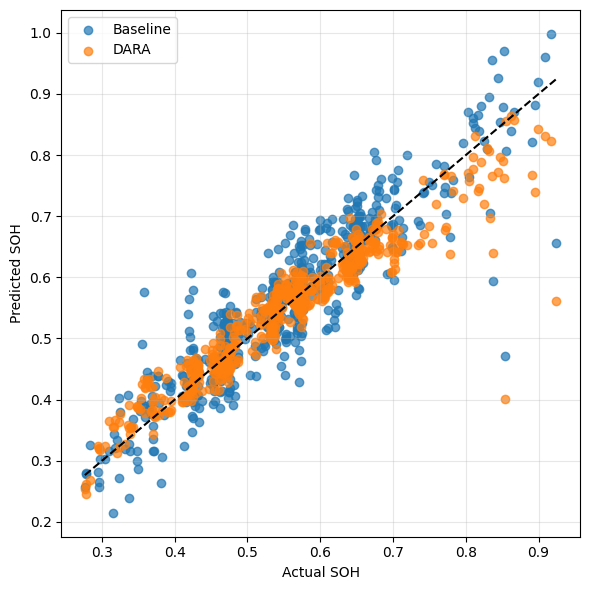

In [122]:
plt.figure(figsize=(6,6))

plt.scatter(
    baseline_result["true"],
    baseline_result["pred"],
    alpha=0.7,
    label="Baseline"
)

plt.scatter(
    dara_result["true"],
    dara_result["pred"],
    alpha=0.7,
    label="DARA"
)

mn = min(baseline_result["true"])
mx = max(baseline_result["true"])

plt.plot([mn,mx],[mn,mx],'k--')

plt.xlabel("Actual SOH")

plt.ylabel("Predicted SOH")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("Figure_Scatter.png", dpi=600)

plt.show()

# The scatter plot of 'Actual vs Predicted SOH' visually compares the true SOH values against the predictions from both the Baseline RSNN and DARA-RSNN models. Here's what it concludes:

# Superior Accuracy of DARA-RSNN: The scatter points for the DARA-RSNN model (orange) are clustered much more tightly around the black dashed diagonal line, which represents perfect prediction (Actual SOH = Predicted SOH). This indicates that DARA-RSNN's predictions are consistently closer to the true SOH values across the range of SOH.
# Higher Variance in Baseline RSNN: The scatter points for the Baseline RSNN model (blue) are more spread out and deviate further from the ideal diagonal line. This suggests that the Baseline model has higher prediction errors and is less accurate compared to DARA-RSNN.
# Consistency Across Range: The DARA-RSNN maintains its tighter clustering around the diagonal line even at different SOH levels, demonstrating more consistent and reliable performance across the entire operating range of the battery. The Baseline RSNN shows greater variability in its predictions, especially at higher SOH values.
# In essence, the scatter plot visually reinforces that the DARA-RSNN model provides significantly more accurate and reliable SOH predictions than the Baseline RSNN model, with its predictions closely aligning with the actual SOH values.#

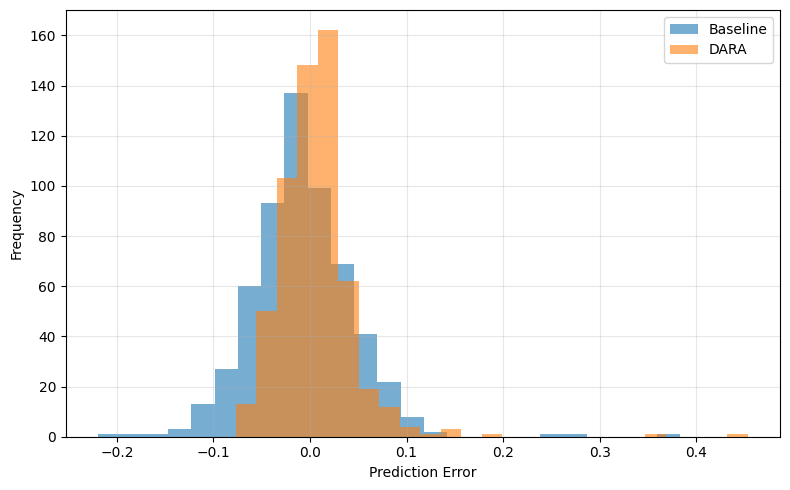

In [123]:
plt.figure(figsize=(8,5))

plt.hist(baseline_error,
         bins=25,
         alpha=0.6,
         label="Baseline")

plt.hist(dara_error,
         bins=25,
         alpha=0.6,
         label="DARA")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("Figure_Error_Histogram.png", dpi=600)

plt.show()

# The Prediction Error Distribution graph, also known as the Error Histogram, provides a clear conclusion regarding the performance of both models:

# DARA-RSNN's error distribution is noticeably narrower and more sharply peaked around zero, suggesting a higher frequency of very small errors. In contrast, the Baseline RSNN's distribution is wider, indicating a broader range of errors. This highlights that the DARA model generally produces smaller and more consistent errors.

In [125]:
print(type(baseline_history))

print(baseline_history.keys())

<class 'dict'>
dict_keys(['train_rmse', 'val_rmse', 'train_mae', 'val_mae'])


In [127]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'os', 'glob', 'random', 'warnings', 'np', 'pd', 'plt', 'mticker', 'MinMaxScaler', 'train_test_split', 'mean_squared_error', 'mean_absolute_error', 'r2_score', 'torch', 'nn', 'F', 'Dataset', 'DataLoader', 'SEED', 'DEVICE', '_i2', 'DATASET_NAME', 'DATASET_PATH', 'FEATURE_COLUMNS', 'TARGET_COLUMN', 'SEQUENCE_LENGTH', 'STRIDE', 'TRAIN_RATIO', 'VAL_RATIO', 'TEST_RATIO', 'BATCH_SIZE', 'EPOCHS', 'LEARNING_RATE', 'TIME_STEPS', 'RESERVOIR_SIZE', 'RESERVOIR_DENSITY', 'LEAK_BETA', 'THRESHOLD', 'NEURONS_PER_FEATURE', '_i3', 'csv_files', 'all_data', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_i10', '_i11', 'i', 'file', 'df', 'battery_df', '_i12', 'duplicates', 'corr', 'im', '_i13', 'soc_corr', '_i14', 'create_sequences', 'X', 'y', '_i15', 'create_sequences_single', 'X_list', 'y_list', 

In [128]:
print(type(history))
print(history.keys())

<class 'dict'>
dict_keys(['train_rmse', 'val_rmse', 'train_mae', 'val_mae', 'lr'])


In [129]:
print("Baseline first 5 RMSE:")
print(baseline_history["train_rmse"][:5])

print("\nHistory first 5 RMSE:")
print(history["train_rmse"][:5])

Baseline first 5 RMSE:
[np.float64(0.3006148844688671), np.float64(0.0404637418414395), np.float64(0.03625211799686949), np.float64(0.03450486663916876), np.float64(0.03326071143011469)]

History first 5 RMSE:
[np.float64(0.08450050304292826), np.float64(0.02858481219190943), np.float64(0.024360183716477087), np.float64(0.022207888356213092), np.float64(0.02083304149801794)]


In [130]:
print("Baseline final RMSE :", baseline_history["train_rmse"][-1])
print("History final RMSE  :", history["train_rmse"][-1])

Baseline final RMSE : 0.015066471333853177
History final RMSE  : 0.01328161384205168


In [131]:
dara_history = history

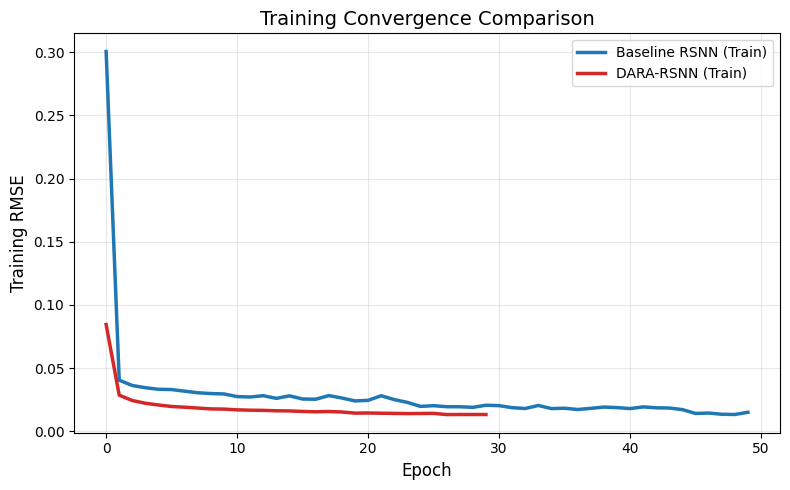

In [132]:
plt.figure(figsize=(8,5))

# Baseline
plt.plot(
    baseline_history["train_rmse"],
    color="#1f77b4",
    linewidth=2.5,
    label="Baseline RSNN (Train)"
)

# DARA
plt.plot(
    dara_history["train_rmse"],
    color="#d62728",
    linewidth=2.5,
    label="DARA-RSNN (Train)"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Training RMSE", fontsize=12)
plt.title("Training Convergence Comparison", fontsize=14)

plt.grid(alpha=0.3)
plt.legend(frameon=True)

plt.tight_layout()
plt.savefig("Training_Convergence_RMSE.png", dpi=600)
plt.show()

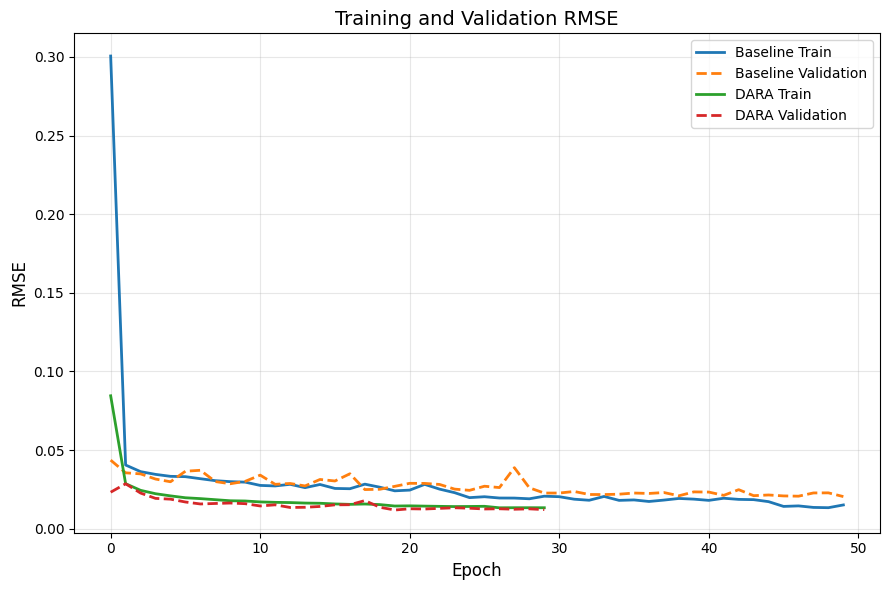

In [133]:
plt.figure(figsize=(9,6))

plt.plot(
    baseline_history["train_rmse"],
    label="Baseline Train",
    linewidth=2
)

plt.plot(
    baseline_history["val_rmse"],
    '--',
    linewidth=2,
    label="Baseline Validation"
)

plt.plot(
    dara_history["train_rmse"],
    linewidth=2,
    label="DARA Train"
)

plt.plot(
    dara_history["val_rmse"],
    '--',
    linewidth=2,
    label="DARA Validation"
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("Training and Validation RMSE", fontsize=14)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("Training_Validation_RMSE.png", dpi=600)
plt.show()

In [134]:
# ---------- Bland–Altman Data ----------

true = np.array(dara_result["true"])
pred = np.array(dara_result["pred"])

mean_values = (true + pred) / 2
difference = pred - true

bias = np.mean(difference)
std = np.std(difference)

upper = bias + 1.96 * std
lower = bias - 1.96 * std

print("Bias :", bias)
print("Upper LoA :", upper)
print("Lower LoA :", lower)

Bias : -0.006326111
Upper LoA : 0.0739403
Lower LoA : -0.08659252


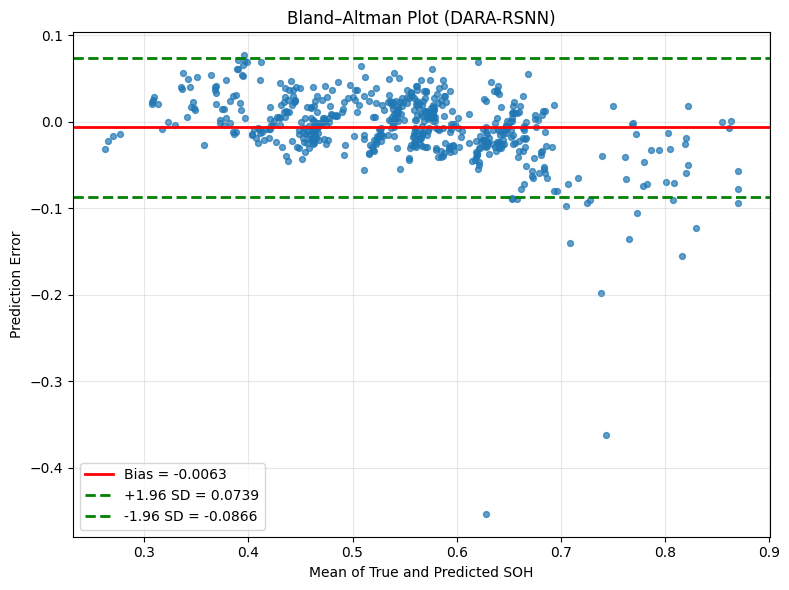

In [135]:
plt.figure(figsize=(8,6))

plt.scatter(
    mean_values,
    difference,
    s=18,
    alpha=0.7
)

plt.axhline(
    bias,
    color='red',
    linestyle='-',
    linewidth=2,
    label=f'Bias = {bias:.4f}'
)

plt.axhline(
    upper,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'+1.96 SD = {upper:.4f}'
)

plt.axhline(
    lower,
    color='green',
    linestyle='--',
    linewidth=2,
    label=f'-1.96 SD = {lower:.4f}'
)

plt.xlabel("Mean of True and Predicted SOH")
plt.ylabel("Prediction Error")

plt.title("Bland–Altman Plot (DARA-RSNN)")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig("Figure_BlandAltman.png", dpi=600)

plt.show()

In [137]:
print("Baseline min:", baseline_error.min())
print("Baseline max:", baseline_error.max())

print("DARA min:", dara_error.min())
print("DARA max:", dara_error.max())

Baseline min: -0.2192274
Baseline max: 0.3830558
DARA min: -0.07665959
DARA max: 0.45296514


In [138]:
# Absolute errors (new variables)

baseline_abs_error = np.abs(
    baseline_result["pred"] - baseline_result["true"]
)

dara_abs_error = np.abs(
    dara_result["pred"] - dara_result["true"]
)

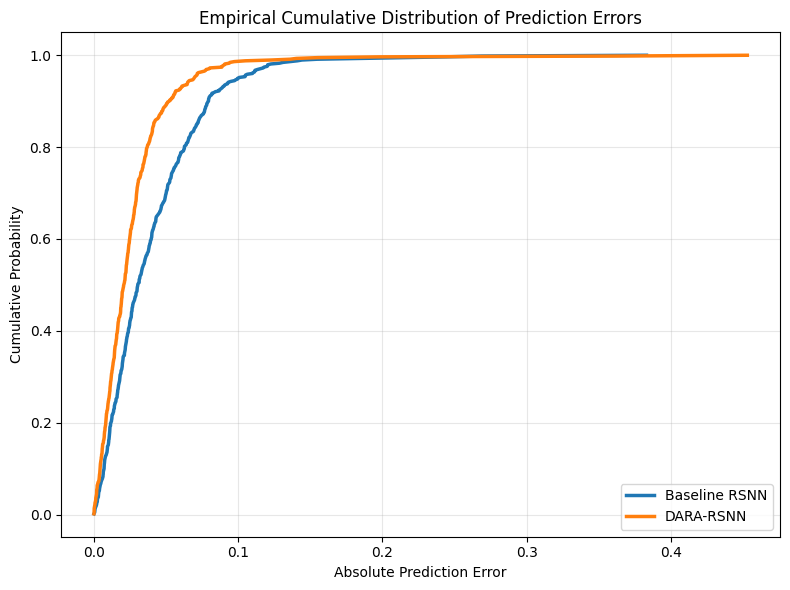

In [139]:
plt.figure(figsize=(8,6))

# Sort errors
baseline_sorted = np.sort(baseline_abs_error)
dara_sorted = np.sort(dara_abs_error)
# Empirical cumulative probability
baseline_cdf = np.arange(1, len(baseline_sorted)+1) / len(baseline_sorted)
dara_cdf = np.arange(1, len(dara_sorted)+1) / len(dara_sorted)

plt.plot(
    baseline_sorted,
    baseline_cdf,
    linewidth=2.5,
    label="Baseline RSNN"
)

plt.plot(
    dara_sorted,
    dara_cdf,
    linewidth=2.5,
    label="DARA-RSNN"
)

plt.xlabel("Absolute Prediction Error")
plt.ylabel("Cumulative Probability")

plt.title("Empirical Cumulative Distribution of Prediction Errors")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig("Figure_ECDF_Error.png", dpi=600)

plt.show()

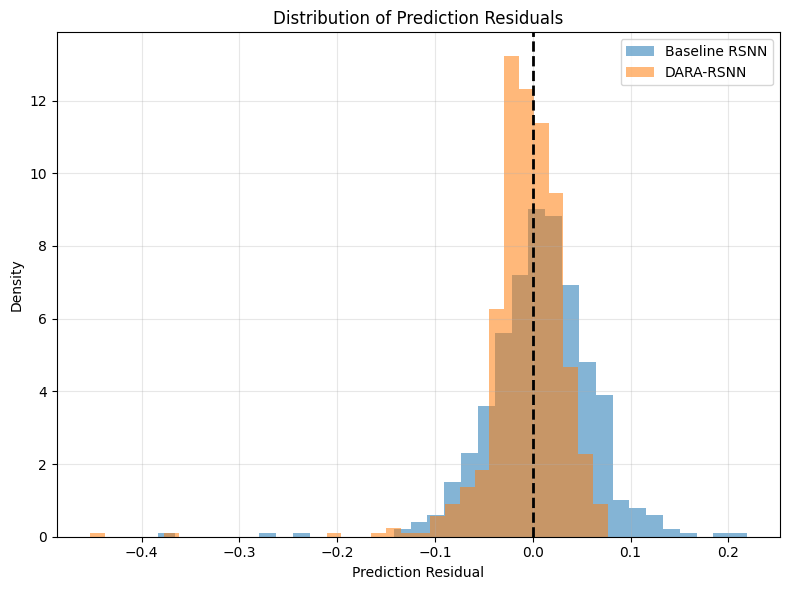

In [141]:
plt.figure(figsize=(8,6))

baseline_residual = baseline_result["pred"] - baseline_result["true"]
dara_residual = dara_result["pred"] - dara_result["true"]

plt.hist(
    baseline_residual,
    bins=35,
    alpha=0.55,
    density=True,
    label="Baseline RSNN"
)

plt.hist(
    dara_residual,
    bins=35,
    alpha=0.55,
    density=True,
    label="DARA-RSNN"
)

plt.axvline(0, color='black', linestyle='--', linewidth=2)

plt.xlabel("Prediction Residual")
plt.ylabel("Density")
plt.title("Distribution of Prediction Residuals")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Figure_Residual_Distribution.png", dpi=600)
plt.show()

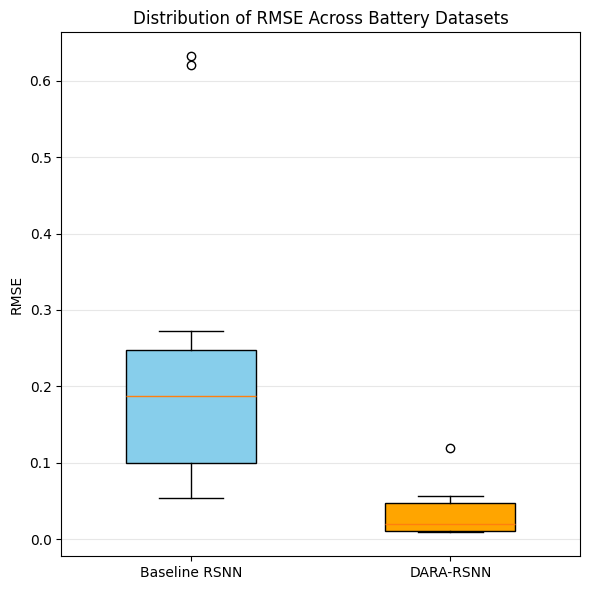

In [142]:
plt.figure(figsize=(6,6))

box = plt.boxplot(
    [
        results_df["Baseline RMSE"],
        results_df["DARA RMSE"]
    ],
    labels=["Baseline RSNN","DARA-RSNN"],
    patch_artist=True,
    widths=0.5
)

box["boxes"][0].set_facecolor("skyblue")
box["boxes"][1].set_facecolor("orange")

plt.ylabel("RMSE")
plt.title("Distribution of RMSE Across Battery Datasets")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("Figure_Boxplot_RMSE.png", dpi=600)

plt.show()

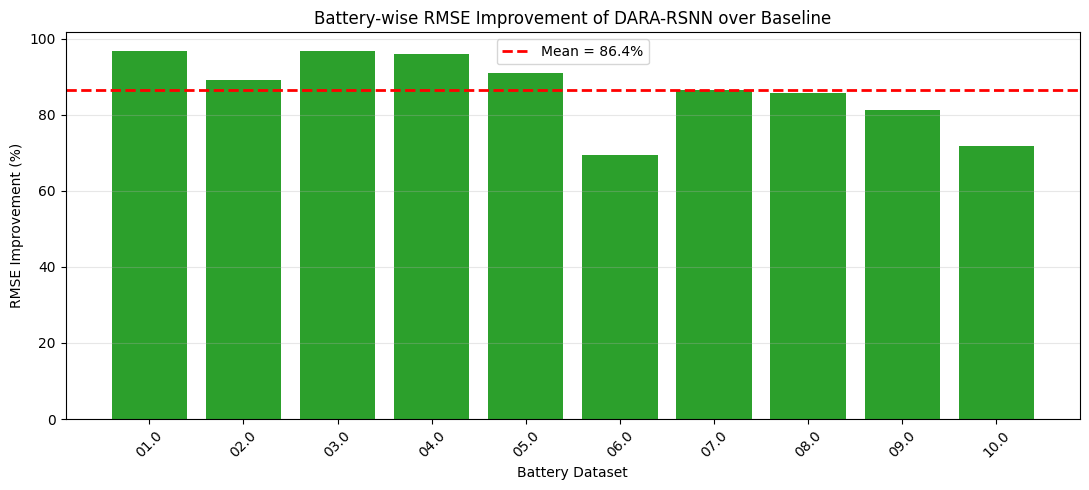

In [143]:
plt.figure(figsize=(11,5))

battery_names = [
    b.split("__")[0]
    for b in results_df["Battery"]
]

plt.bar(
    battery_names,
    results_df["RMSE Improvement (%)"],
    color="tab:green"
)

plt.axhline(
    results_df["RMSE Improvement (%)"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {results_df['RMSE Improvement (%)'].mean():.1f}%"
)

plt.ylabel("RMSE Improvement (%)")
plt.xlabel("Battery Dataset")
plt.title("Battery-wise RMSE Improvement of DARA-RSNN over Baseline")

plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig("Figure_Batterywise_Improvement.png", dpi=600)

plt.show()